This notebook is to gather indivudual results from the comet log file for different scenarios for all methods.

In [3]:
import sys
from comet_ml import API, Experiment
sys.path.append(".")

from utils import *

In [4]:
api = API(api_key="V1x7OI9PoIRM8yze4prM2FPcE")  # Replace with your actual Comet API key

In [5]:
workspace = "b-acharya"  # Replace with your Comet workspace name

#this is different for each project
project_name = "strat-exp1"  # Replace with your project name


In [6]:
experiments = api.get_experiments(workspace=workspace, project_name=project_name)

In [7]:
len(experiments)

334

# CMBP

In [8]:
#COHFACE and differnt models

CMBP_tscan_experiments = []
CMBP_deepphys_experiments = []
CMBP_rppgnet_experiments = []
CMBP_physnet_experiments = []

for experiment in experiments:
    print(f"Experiment Name: {experiment.name}")
    experiment_name = experiment.name

    if "CMBP" in experiment_name and "Tscan" in experiment_name:
        if "arxiv" in experiment.get_tags():
            CMBP_tscan_experiments.append(experiment)
        continue

    elif "CMBP" in experiment_name and "DeepPhys" in experiment_name:
        if "arxiv" in experiment.get_tags():
            CMBP_deepphys_experiments.append(experiment)
        continue

    elif "CMBP" in experiment_name and "Physnet" in experiment_name:
        CMBP_physnet_experiments.append(experiment)
        continue

    elif "CMBP" in experiment_name and "rPPGNet" in experiment_name:
        CMBP_rppgnet_experiments.append(experiment)
        continue

Experiment Name: CMBP_DeepPhys_FOLD_0
Experiment Name: CMBP_DeepPhys_FOLD_1
Experiment Name: CMBP_DeepPhys_FOLD_2
Experiment Name: CMBP_DeepPhys_FOLD_3
Experiment Name: CMBP_DeepPhys_FOLD_4
Experiment Name: CMBP_DeepPhys_FOLD_5
Experiment Name: CMBP_DeepPhys_FOLD_6
Experiment Name: CMBP_DeepPhys_FOLD_7
Experiment Name: CMBP_DeepPhys_FOLD_8
Experiment Name: CMBP_DeepPhys_FOLD_9
Experiment Name: CMBP_DeepPhys_FOLD_0
Experiment Name: CMBP_DeepPhys_FOLD_1
Experiment Name: CMBP_DeepPhys_FOLD_2
Experiment Name: CMBP_DeepPhys_FOLD_3
Experiment Name: CMBP_DeepPhys_FOLD_4
Experiment Name: CMBP_DeepPhys_FOLD_5
Experiment Name: CMBP_DeepPhys_FOLD_6
Experiment Name: CMBP_DeepPhys_FOLD_7
Experiment Name: CMBP_DeepPhys_FOLD_8
Experiment Name: CMBP_DeepPhys_FOLD_9
Experiment Name: PURE_DeepPhys_FOLD_0
Experiment Name: PURE_DeepPhys_FOLD_1
Experiment Name: PURE_DeepPhys_FOLD_2
Experiment Name: COHFACE_DeepPhys_FOLD_0
Experiment Name: PURE_DeepPhys_FOLD_3
Experiment Name: COHFACE_DeepPhys_FOLD_1
Experi

In [9]:
len(CMBP_tscan_experiments), len(CMBP_deepphys_experiments), len(CMBP_rppgnet_experiments), len(CMBP_physnet_experiments)

(10, 10, 10, 10)

In [10]:
deepPhys_CMBP_df = get_dataframe(CMBP_deepphys_experiments)

tscan_CMBP_df = get_dataframe(CMBP_tscan_experiments)

physnet_CMBP_df = get_dataframe(CMBP_physnet_experiments)

rppgnet_CMBP_df = get_dataframe(CMBP_rppgnet_experiments)


In [11]:
len(deepPhys_CMBP_df), len(rppgnet_CMBP_df), len(tscan_CMBP_df), len(physnet_CMBP_df)

(180, 180, 180, 180)

In [12]:

fold_CMBP_mae_deepphys_df = deepPhys_CMBP_df.groupby('FOLD')['Error'].mean()
fold_CMBP_mae_tscan_df = tscan_CMBP_df.groupby('FOLD')['Error'].mean()
fold_CMBP_mae_physnet_df = physnet_CMBP_df.groupby('FOLD')['Error'].mean()
fold_CMBP_mae_rppgnet_df = rppgnet_CMBP_df.groupby('FOLD')['Error'].mean()

print(fold_CMBP_mae_deepphys_df.mean())
print(fold_CMBP_mae_tscan_df.mean())
print(fold_CMBP_mae_physnet_df.mean())
print(fold_CMBP_mae_rppgnet_df.mean())

9.1058349609375
3.19061279296875
4.11712646484375
2.01324462890625


In [13]:
def modify_datafram_CMBP(df):
    df.reset_index(inplace=True)
    df['scenario'] = df['Participant-ID'].str[-1:].astype(int)
    df['Participant'] = df['Participant-ID'].str[2:-2]
    return df

deepPhys_CMBP_df = modify_datafram_CMBP(deepPhys_CMBP_df)
tscan_CMBP_df = modify_datafram_CMBP(tscan_CMBP_df)
physnet_CMBP_df = modify_datafram_CMBP(physnet_CMBP_df)
rppgnet_CMBP_df = modify_datafram_CMBP(rppgnet_CMBP_df)

In [14]:
deepPhys_CMBP_df

,FOLD,Participant-ID,GT_HR,Pred_HR,Error,scenario,Participant
0,0,0_NC33214245_0,89.355469,89.355469,0.000000,0,NC33214245
1,0,0_NC33214245_1,97.412109,98.876953,1.464844,1,NC33214245
2,0,0_NC33214245_2,112.060547,111.328125,0.732422,2,NC33214245
3,0,0_NC33214245_3,98.876953,95.947266,2.929688,3,NC33214245
4,0,0_ND35324245_0,80.566406,79.833984,0.732422,0,ND35324245
...,...,...,...,...,...,...,...
175,9,0_NN30214245_3,80.566406,80.566406,0.000000,3,NN30214245
176,9,0_PI34324245_0,82.763672,82.031250,0.732422,0,PI34324245
177,9,0_PI34324245_1,82.031250,82.031250,0.000000,1,PI34324245
178,9,0_PI34324245_2,81.298828,82.763672,1.464844,2,PI34324245


In [15]:
models = [ deepPhys_CMBP_df, tscan_CMBP_df, physnet_CMBP_df, rppgnet_CMBP_df ]
model_names = ["deepPhys", "tscan", "physnet", "rppgnet"]

results_CMBP = []
dataset = "CMBP"

for model, model_name in zip(models, model_names):

    ttest_metrics = perform_ttest_per_fold(model, model_name, dataset, type="Illumination", debug=False)
    results_CMBP.append(ttest_metrics)

results_df = pd.DataFrame(results_CMBP)
results_df

Common Folds: {'2', '9', '7', '5', '8', '4', '0', '3', '1', '6'}
Test Used: Paired t-test
Test Used: 0.5894156344365918
p-value: 0.57008
cohen_d: 0.18639
effect_size_r: nan
No significant difference detected between scenarios.
Common Folds: {'2', '9', '7', '5', '8', '4', '0', '3', '1', '6'}
Test Used: Wilcoxon signed-rank test
Test Used: 7.0
p-value: 0.23672
cohen_d: -0.38742
effect_size_r: -0.66077
No significant difference detected between scenarios.
Common Folds: {'2', '9', '7', '5', '8', '4', '0', '3', '1', '6'}
Test Used: Paired t-test
Test Used: 0.6704281748410275
p-value: 0.51942
cohen_d: 0.21201
effect_size_r: nan
No significant difference detected between scenarios.
Common Folds: {'2', '9', '7', '5', '8', '4', '0', '3', '1', '6'}
Test Used: Wilcoxon signed-rank test
Test Used: 24.0
p-value: 0.76953
cohen_d: 0.37970
effect_size_r: -0.11282
No significant difference detected between scenarios.


/homes/bacharya/miniconda3/envs/toolbox/lib/python3.8/site-packages/scipy/stats/morestats.py:2957: UserWarning: Exact p-value calculation does not work if there are ties. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/homes/bacharya/miniconda3/envs/toolbox/lib/python3.8/site-packages/scipy/stats/morestats.py:2971: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")


,Model,Test Used,t-statistic,p-value,cohen-d,effect-size-r
0,deepPhys,Paired t-test,0.589416,0.570,0.186,NaN
1,tscan,Wilcoxon signed-rank test,7.000000,0.237,-0.387,-0.661
2,physnet,Paired t-test,0.670428,0.519,0.212,NaN
3,rppgnet,Wilcoxon signed-rank test,24.000000,0.770,0.380,-0.113


In [16]:
results_CMBP = []
dataset = "CMBP"

for model, model_name in zip(models, model_names):

    ttest_overall_metrics = perform_ttest_participant(model, model_name, dataset, type="Illumination", debug=True)
    results_CMBP.append(ttest_overall_metrics)

results_df = pd.DataFrame(results_CMBP)
results_df

Scenarios 0 and 1
    FOLD  Participant-ID       GT_HR     Pred_HR      Error  scenario  \
1      0  0_NC33214245_1   97.412109   98.876953   1.464844         1   
2      0  0_NC33214245_2  112.060547  111.328125   0.732422         2   
5      0  0_ND35324245_1   84.228516   84.960938   0.732422         1   
6      0  0_ND35324245_2  125.244141   63.720703  61.523438         2   
9      0  0_OD35324245_1   85.693359   84.228516   1.464844         1   
..   ...             ...         ...         ...        ...       ...   
170    9  0_IH29344245_2   86.425781   85.693359   0.732422         2   
173    9  0_NN30214245_1   66.650391   74.707031   8.056641         1   
174    9  0_NN30214245_2   84.228516   83.496094   0.732422         2   
177    9  0_PI34324245_1   82.031250   82.031250   0.000000         1   
178    9  0_PI34324245_2   81.298828   82.763672   1.464844         2   

    Participant  
1    NC33214245  
2    NC33214245  
5    ND35324245  
6    ND35324245  
9    OD35324245

,Model,Test Used,t-statistic,p-value,cohen-d,effect-size-r
0,deepPhys,Wilcoxon signed-rank test,466.0,0.933,0.061,-0.087
1,tscan,Wilcoxon signed-rank test,373.5,0.622,-0.202,-0.242
2,physnet,Wilcoxon signed-rank test,301.0,0.092,0.151,-0.364
3,rppgnet,Wilcoxon signed-rank test,385.0,0.735,0.187,-0.223


<Axes: xlabel='GT_HR', ylabel='Count'>

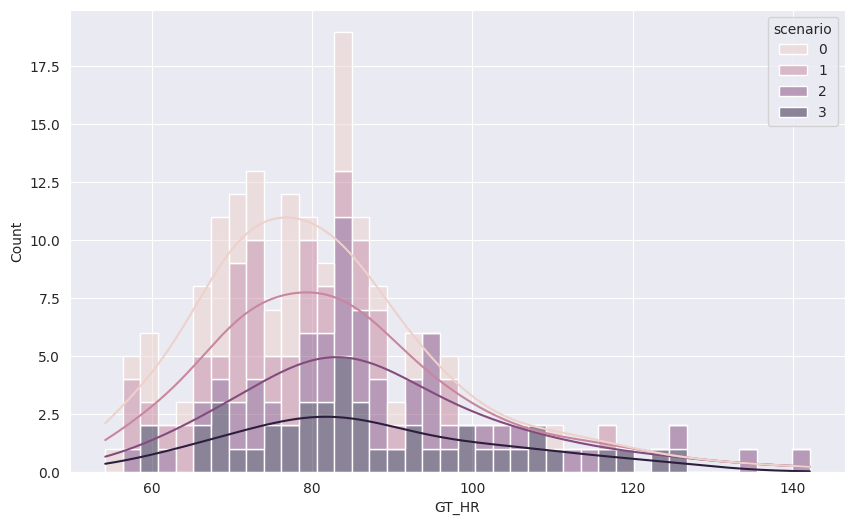

In [17]:
model
plt.figure(figsize=(10, 6))
sns.histplot(data=model, x='GT_HR', hue='scenario', bins=40, kde=True, multiple="stack")

In [18]:
HIGH = 90

low_hr_mask = model['scenario'].isin([0,1])
high_hr_mask = model['scenario'].isin([2,3])

low_hr_df = model[low_hr_mask]
high_hr_df = model[high_hr_mask]

# low_hr_df = low_hr_df[low_hr_df['GT_HR']< HIGH].reset_index(drop=True)
# high_hr_df = high_hr_df[high_hr_df['GT_HR']>= HIGH].reset_index(drop=True)

In [19]:
high_hr_df

,FOLD,Participant-ID,GT_HR,Pred_HR,Error,scenario,Participant
2,0,0_NC33214245_2,112.792969,113.525391,0.732422,2,NC33214245
3,0,0_NC33214245_3,98.144531,95.947266,2.197266,3,NC33214245
6,0,0_ND35324245_2,125.976562,122.314453,3.662109,2,ND35324245
7,0,0_ND35324245_3,97.412109,98.144531,0.732422,3,ND35324245
10,0,0_OD35324245_2,104.003906,103.271484,0.732422,2,OD35324245
...,...,...,...,...,...,...,...
171,9,0_IH29344245_3,68.847656,69.580078,0.732422,3,IH29344245
174,9,0_NN30214245_2,84.228516,84.228516,0.000000,2,NN30214245
175,9,0_NN30214245_3,81.298828,82.763672,1.464844,3,NN30214245
178,9,0_PI34324245_2,81.298828,81.298828,0.000000,2,PI34324245


<Axes: xlabel='GT_HR', ylabel='Error'>

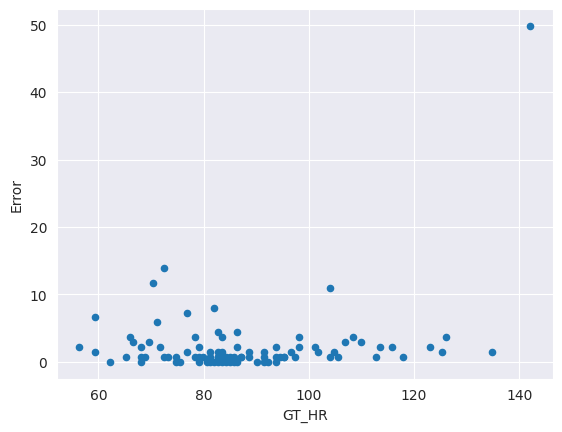

In [20]:
high_hr_df.plot.scatter(x='GT_HR', y='Error')

array([[<Axes: title={'center': 'GT_HR'}>]], dtype=object)

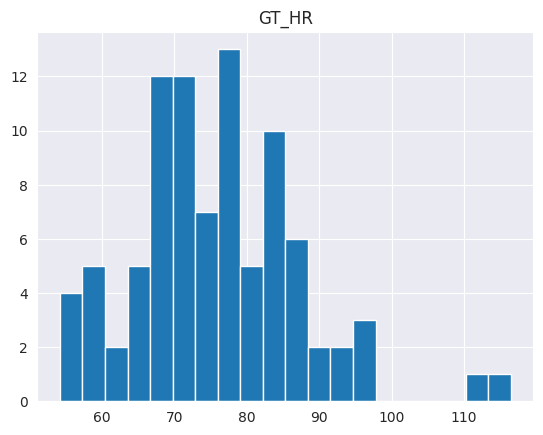

In [21]:
low_hr_df.hist(column='GT_HR', bins=20)

array([[<Axes: title={'center': 'GT_HR'}>]], dtype=object)

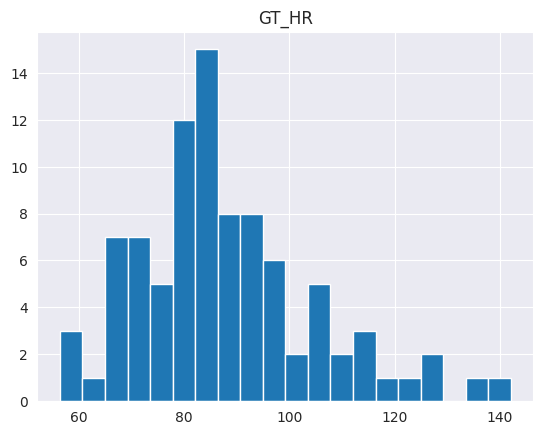

In [22]:
high_hr_df.hist(column='GT_HR', bins=20)

In [23]:
# low_hr_df, high_hr_df
len(high_hr_df[high_hr_df['Participant'].isin(low_hr_df['Participant'])]['Participant'])

90

In [24]:
len(high_hr_df['Participant'].unique())

45

In [25]:
high_hr_df[high_hr_df['Participant'].isin(low_hr_df['Participant'])]

,FOLD,Participant-ID,GT_HR,Pred_HR,Error,scenario,Participant
2,0,0_NC33214245_2,112.792969,113.525391,0.732422,2,NC33214245
3,0,0_NC33214245_3,98.144531,95.947266,2.197266,3,NC33214245
6,0,0_ND35324245_2,125.976562,122.314453,3.662109,2,ND35324245
7,0,0_ND35324245_3,97.412109,98.144531,0.732422,3,ND35324245
10,0,0_OD35324245_2,104.003906,103.271484,0.732422,2,OD35324245
...,...,...,...,...,...,...,...
171,9,0_IH29344245_3,68.847656,69.580078,0.732422,3,IH29344245
174,9,0_NN30214245_2,84.228516,84.228516,0.000000,2,NN30214245
175,9,0_NN30214245_3,81.298828,82.763672,1.464844,3,NN30214245
178,9,0_PI34324245_2,81.298828,81.298828,0.000000,2,PI34324245


In [26]:
len(low_hr_df[low_hr_df['Participant'].isin(high_hr_df['Participant'])]['Participant'].unique())

45

In [27]:
low_hr_df[low_hr_df['Participant'].isin(high_hr_df['Participant'])]

,FOLD,Participant-ID,GT_HR,Pred_HR,Error,scenario,Participant
0,0,0_NC33214245_0,89.355469,89.355469,0.000000,0,NC33214245
1,0,0_NC33214245_1,97.412109,98.144531,0.732422,1,NC33214245
4,0,0_ND35324245_0,80.566406,80.566406,0.000000,0,ND35324245
5,0,0_ND35324245_1,84.960938,84.960938,0.000000,1,ND35324245
8,0,0_OD35324245_0,82.763672,82.763672,0.000000,0,OD35324245
...,...,...,...,...,...,...,...
169,9,0_IH29344245_1,56.396484,55.664062,0.732422,1,IH29344245
172,9,0_NN30214245_0,65.917969,66.650391,0.732422,0,NN30214245
173,9,0_NN30214245_1,65.917969,65.917969,0.000000,1,NN30214245
176,9,0_PI34324245_0,82.763672,83.496094,0.732422,0,PI34324245


In [28]:
merged_df = high_hr_df.merge(low_hr_df, on='Participant', how='inner', suffixes=('_df1', '_df2'), indicator=True)
# merged_df[['Participant-ID_df1', 'Participant-ID_df2']]
merged_df

,FOLD_df1,Participant-ID_df1,GT_HR_df1,Pred_HR_df1,Error_df1,scenario_df1,Participant,FOLD_df2,Participant-ID_df2,GT_HR_df2,Pred_HR_df2,Error_df2,scenario_df2,_merge
0,0,0_NC33214245_2,112.792969,113.525391,0.732422,2,NC33214245,0,0_NC33214245_0,89.355469,89.355469,0.000000,0,both
1,0,0_NC33214245_2,112.792969,113.525391,0.732422,2,NC33214245,0,0_NC33214245_1,97.412109,98.144531,0.732422,1,both
2,0,0_NC33214245_3,98.144531,95.947266,2.197266,3,NC33214245,0,0_NC33214245_0,89.355469,89.355469,0.000000,0,both
3,0,0_NC33214245_3,98.144531,95.947266,2.197266,3,NC33214245,0,0_NC33214245_1,97.412109,98.144531,0.732422,1,both
4,0,0_ND35324245_2,125.976562,122.314453,3.662109,2,ND35324245,0,0_ND35324245_0,80.566406,80.566406,0.000000,0,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,9,0_NN30214245_3,81.298828,82.763672,1.464844,3,NN30214245,9,0_NN30214245_1,65.917969,65.917969,0.000000,1,both
176,9,0_PI34324245_2,81.298828,81.298828,0.000000,2,PI34324245,9,0_PI34324245_0,82.763672,83.496094,0.732422,0,both
177,9,0_PI34324245_2,81.298828,81.298828,0.000000,2,PI34324245,9,0_PI34324245_1,82.031250,83.496094,1.464844,1,both
178,9,0_PI34324245_3,78.369141,77.636719,0.732422,3,PI34324245,9,0_PI34324245_0,82.763672,83.496094,0.732422,0,both


In [29]:
pd.set_option('display.max_rows', 500)
print(merged_df)

    FOLD_df1 Participant-ID_df1   GT_HR_df1  Pred_HR_df1  Error_df1  \
0          0     0_NC33214245_2  112.792969   113.525391   0.732422   
1          0     0_NC33214245_2  112.792969   113.525391   0.732422   
2          0     0_NC33214245_3   98.144531    95.947266   2.197266   
3          0     0_NC33214245_3   98.144531    95.947266   2.197266   
4          0     0_ND35324245_2  125.976562   122.314453   3.662109   
5          0     0_ND35324245_2  125.976562   122.314453   3.662109   
6          0     0_ND35324245_3   97.412109    98.144531   0.732422   
7          0     0_ND35324245_3   97.412109    98.144531   0.732422   
8          0     0_OD35324245_2  104.003906   103.271484   0.732422   
9          0     0_OD35324245_2  104.003906   103.271484   0.732422   
10         0     0_OD35324245_3  105.468750   104.736328   0.732422   
11         0     0_OD35324245_3  105.468750   104.736328   0.732422   
12         0     0_RD37214245_2   87.158203    87.890625   0.732422   
13    

In [30]:
results_CMBP = []
dataset = "CMBP"

for model, model_name in zip(models, model_names):

    ttest_overall_metrics = perform_ttest_per_fold(model, model_name, dataset, type="HR", debug=False)
    results_CMBP.append(ttest_overall_metrics)

results_df = pd.DataFrame(results_CMBP)
results_df


Common Folds: {'2', '9', '7', '5', '8', '4', '0', '3', '1', '6'}
Test Used: Paired t-test
Test Used: 2.3534667542485397
p-value: 0.04306
cohen_d: 0.74423
effect_size_r: nan
Significant difference detected between scenarios!
Common Folds: {'2', '9', '7', '5', '8', '4', '0', '3', '1', '6'}
Test Used: Wilcoxon signed-rank test
Test Used: 10.0
p-value: 0.08398
cohen_d: -0.07152
effect_size_r: -0.56408
No significant difference detected between scenarios.
Common Folds: {'2', '9', '7', '5', '8', '4', '0', '3', '1', '6'}
Test Used: Paired t-test
Test Used: 1.0066022947037823
p-value: 0.34042
cohen_d: 0.31832
effect_size_r: nan
No significant difference detected between scenarios.
Common Folds: {'2', '9', '7', '5', '8', '4', '0', '3', '1', '6'}
Test Used: Paired t-test
Test Used: 1.250347522099874
p-value: 0.24270
cohen_d: 0.39539
effect_size_r: nan
No significant difference detected between scenarios.


,Model,Test Used,t-statistic,p-value,cohen-d,effect-size-r
0,deepPhys,Paired t-test,2.353467,0.043,0.744,NaN
1,tscan,Wilcoxon signed-rank test,10.000000,0.084,-0.072,-0.564
2,physnet,Paired t-test,1.006602,0.340,0.318,NaN
3,rppgnet,Paired t-test,1.250348,0.243,0.395,NaN


In [31]:
merged_df.hist(column='GT_HR', bins=20)

KeyError: "None of [Index(['GT_HR'], dtype='object')] are in the [columns]"

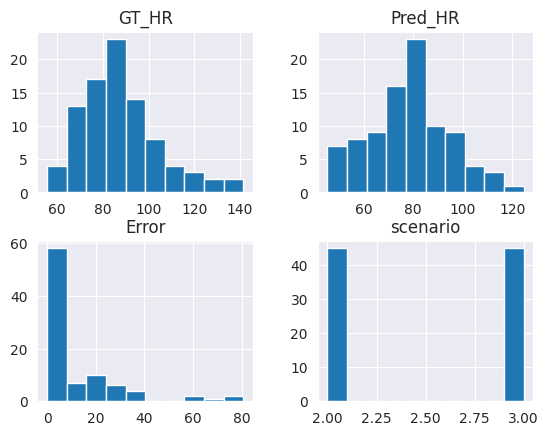

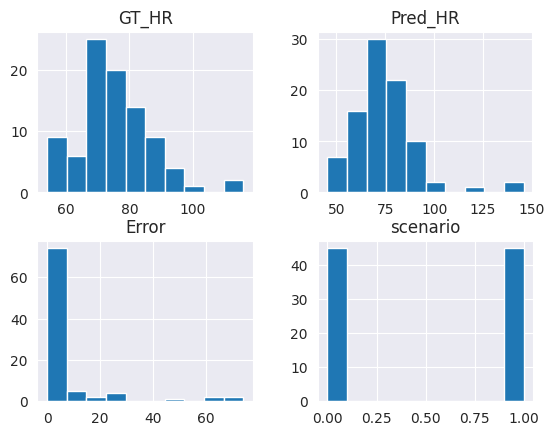

Participant : {'CC36344245', 'HD37214245', 'NB31324245', 'NT31214245', 'OD31324245', 'OD35324245', 'NN30214245', 'VI49324245', 'CU34214245', 'HJ34324245', 'CR42324245', 'HI44214245', 'CJ48324245', 'HB21344245', 'LI36344245', 'VR35324245', 'NN33214245', 'JD31324245', 'CC36214245', 'LD31324245', 'NU34214245', 'LU42324245', 'UG35324245', 'NC33214245', 'NJ20214245', 'GC34324245', 'PI34324245', 'NP44214245', 'VL31214245', 'RD37214245', 'Ec20214245', 'KI35324245', 'ND35324245', 'MY37214245', 'LI34344245', 'ON20344245', 'LY31324245', 'IH29344245', 'AY31324245', 'OY31324245', 'CG43214245', 'LG31214245', 'EY20214245', 'NY20214245', 'VM20214245'}
Test Used: Wilcoxon signed-rank test
Test Used: 182.5
p-value: 0.00015
cohen_d: 0.36736
effect_size_r: -0.56369
Significant difference detected between scenarios!


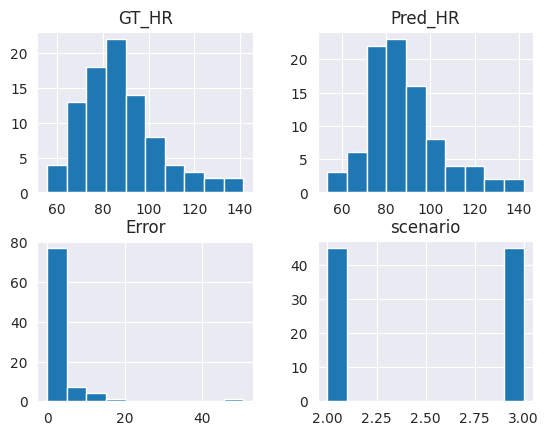

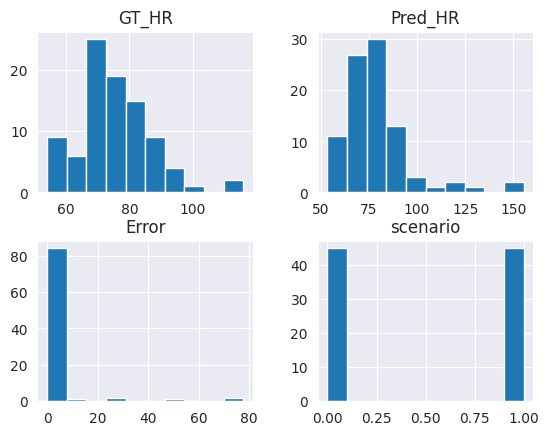

Participant : {'CC36344245', 'HD37214245', 'NB31324245', 'NT31214245', 'OD31324245', 'OD35324245', 'NN30214245', 'VI49324245', 'CU34214245', 'HJ34324245', 'CR42324245', 'HI44214245', 'CJ48324245', 'HB21344245', 'LI36344245', 'VR35324245', 'NN33214245', 'JD31324245', 'CC36214245', 'LD31324245', 'NU34214245', 'LU42324245', 'UG35324245', 'NC33214245', 'NJ20214245', 'GC34324245', 'PI34324245', 'NP44214245', 'VL31214245', 'RD37214245', 'Ec20214245', 'KI35324245', 'ND35324245', 'MY37214245', 'LI34344245', 'ON20344245', 'LY31324245', 'IH29344245', 'AY31324245', 'OY31324245', 'CG43214245', 'LG31214245', 'EY20214245', 'NY20214245', 'VM20214245'}
Test Used: Wilcoxon signed-rank test
Test Used: 200.5
p-value: 0.00799
cohen_d: -0.07152
effect_size_r: -0.53340
Significant difference detected between scenarios!


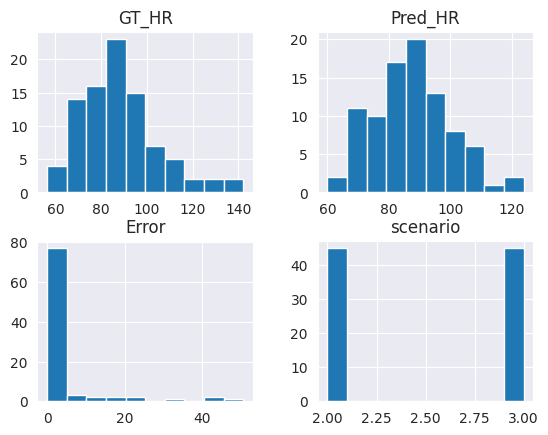

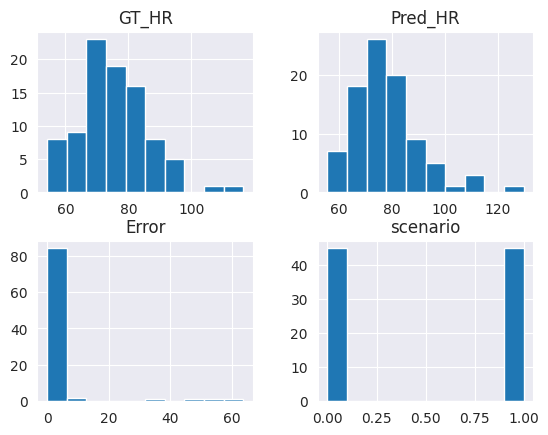

Participant : {'CC36344245', 'HD37214245', 'NB31324245', 'NT31214245', 'OD31324245', 'OD35324245', 'NN30214245', 'VI49324245', 'CU34214245', 'HJ34324245', 'CR42324245', 'HI44214245', 'CJ48324245', 'HB21344245', 'LI36344245', 'VR35324245', 'NN33214245', 'JD31324245', 'CC36214245', 'LD31324245', 'NU34214245', 'LU42324245', 'UG35324245', 'NC33214245', 'NJ20214245', 'GC34324245', 'PI34324245', 'NP44214245', 'VL31214245', 'RD37214245', 'Ec20214245', 'KI35324245', 'ND35324245', 'MY37214245', 'LI34344245', 'ON20344245', 'LY31324245', 'IH29344245', 'AY31324245', 'OY31324245', 'CG43214245', 'LG31214245', 'EY20214245', 'NY20214245', 'VM20214245'}
Test Used: Wilcoxon signed-rank test
Test Used: 144.5
p-value: 0.00021
cohen_d: 0.17600
effect_size_r: -0.62763
Significant difference detected between scenarios!


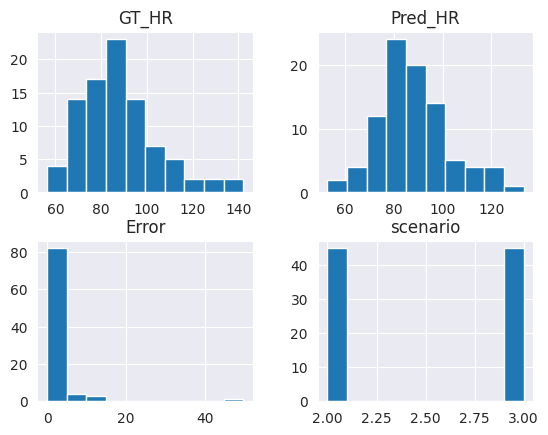

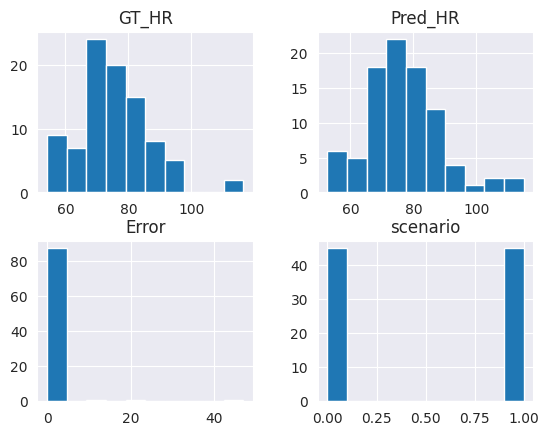

Participant : {'CC36344245', 'HD37214245', 'NB31324245', 'NT31214245', 'OD31324245', 'OD35324245', 'NN30214245', 'VI49324245', 'CU34214245', 'HJ34324245', 'CR42324245', 'HI44214245', 'CJ48324245', 'HB21344245', 'LI36344245', 'VR35324245', 'NN33214245', 'JD31324245', 'CC36214245', 'LD31324245', 'NU34214245', 'LU42324245', 'UG35324245', 'NC33214245', 'NJ20214245', 'GC34324245', 'PI34324245', 'NP44214245', 'VL31214245', 'RD37214245', 'Ec20214245', 'KI35324245', 'ND35324245', 'MY37214245', 'LI34344245', 'ON20344245', 'LY31324245', 'IH29344245', 'AY31324245', 'OY31324245', 'CG43214245', 'LG31214245', 'EY20214245', 'NY20214245', 'VM20214245'}
Test Used: Wilcoxon signed-rank test
Test Used: 223.5
p-value: 0.00251
cohen_d: 0.17767
effect_size_r: -0.49470
Significant difference detected between scenarios!


,Model,Test Used,t-statistic,p-value,cohen-d,effect-size-r
0,deepPhys,Wilcoxon signed-rank test,182.5,0.000,0.367,-0.564
1,tscan,Wilcoxon signed-rank test,200.5,0.008,-0.072,-0.533
2,physnet,Wilcoxon signed-rank test,144.5,0.000,0.176,-0.628
3,rppgnet,Wilcoxon signed-rank test,223.5,0.003,0.178,-0.495


In [20]:
results_CMBP = []
dataset = "CMBP"

for model, model_name in zip(models, model_names):

    ttest_overall_metrics = perform_ttest_participant(model, model_name, dataset, type="HR", debug=False)
    results_CMBP.append(ttest_overall_metrics)

results_df = pd.DataFrame(results_CMBP)
results_df


deepPhys
Using CHILL dataset
Defining scenarios
This is performed on illumination splits


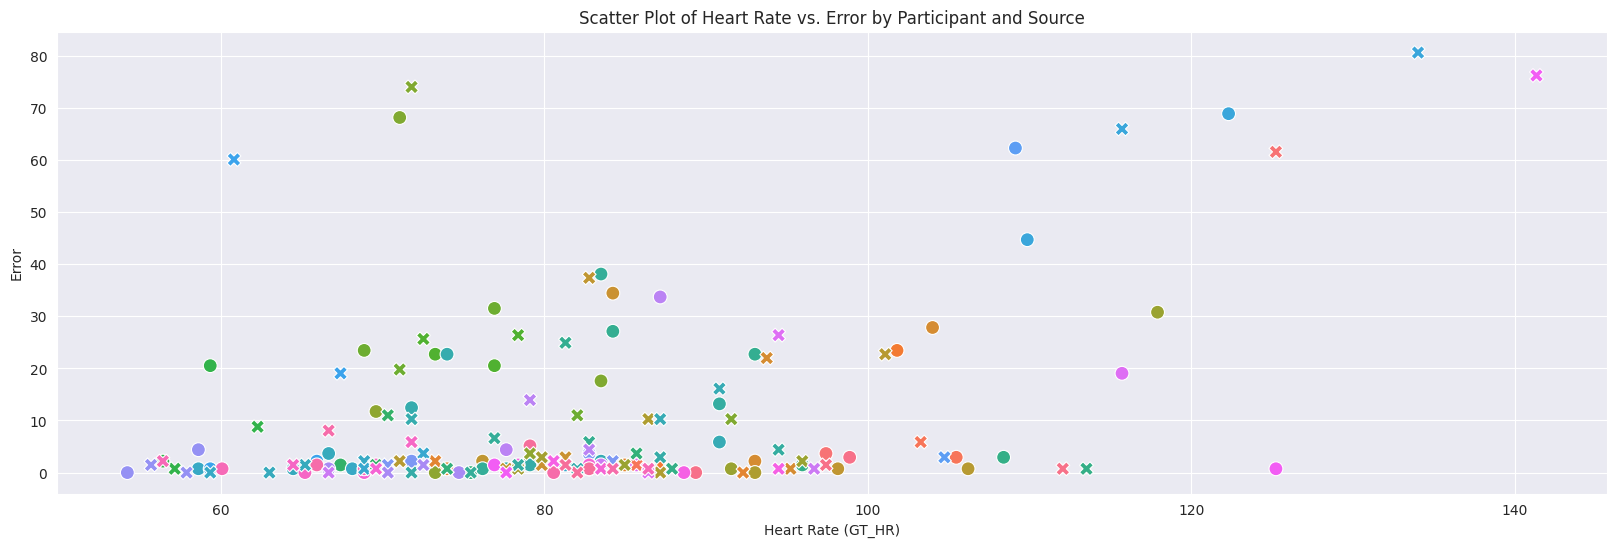

No. of Participants in dataset:  45
---.---.---.---.---.---.---.---.---.---.
HI44214245
2
--
HI44214245
2
--------------------------------------------------
0.732421875 12.451171875
---.---.---.---.---.---.---.---.---.---.
VL31214245
2
--
VL31214245
2
--------------------------------------------------
2.197265625 0.732421875
---.---.---.---.---.---.---.---.---.---.
JD31324245
2
--
JD31324245
2
--------------------------------------------------
0.732421875 6.2255859375
---.---.---.---.---.---.---.---.---.---.
HD37214245
2
--
HD37214245
2
--------------------------------------------------
2.197265625 0.732421875
---.---.---.---.---.---.---.---.---.---.
CC36344245
2
--
CC36344245
2
--------------------------------------------------
1.46484375 39.55078125
---.---.---.---.---.---.---.---.---.---.
ON20344245
2
--
ON20344245
2
--------------------------------------------------
1.0986328125 0.3662109375
---.---.---.---.---.---.---.---.---.---.
MY37214245
2
--
MY37214245
2
---------------------

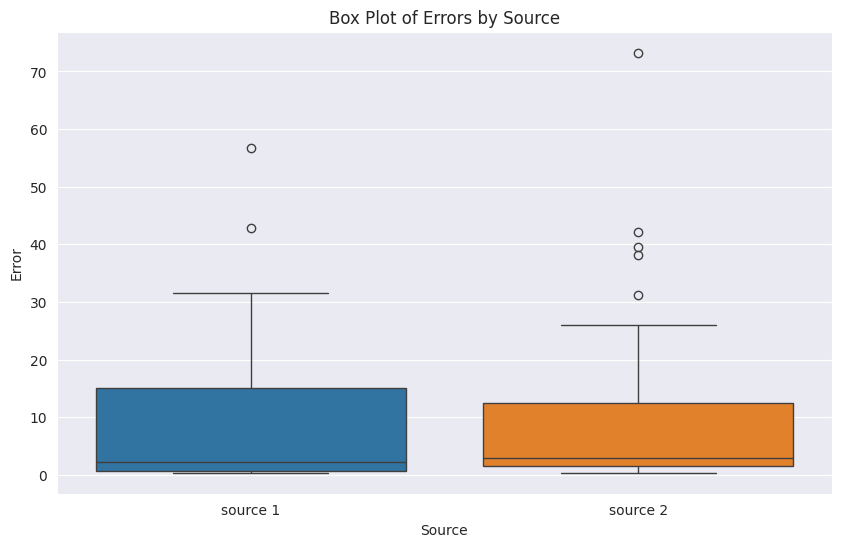

--------------------------------------------------
0    -11.718750
1      1.464844
2     -5.493164
3      1.464844
4    -38.085938
5      0.732422
6     -0.366211
7      6.591797
8      0.000000
9     -1.831055
10    -1.464844
11     3.662109
12    -4.394531
13    -0.366211
14    -0.732422
15     2.197266
16     0.732422
17    16.113281
18    -9.155273
19    -0.366211
20    -0.732422
21    15.380859
22    29.663086
23    -2.929688
24   -28.930664
25     3.295898
26    12.084961
27     1.098633
28    -3.662109
29    13.916016
30     4.028320
31    12.084961
32   -17.578125
33     0.000000
34    10.986328
35    -4.760742
36     0.366211
37     9.521484
38    -2.929688
39   -36.987305
40    -1.831055
41     9.887695
42    -0.366211
43     1.464844
44   -16.479492
dtype: float64
No significant difference detected between scenarios.
tscan
Using CHILL dataset
Defining scenarios
This is performed on illumination splits


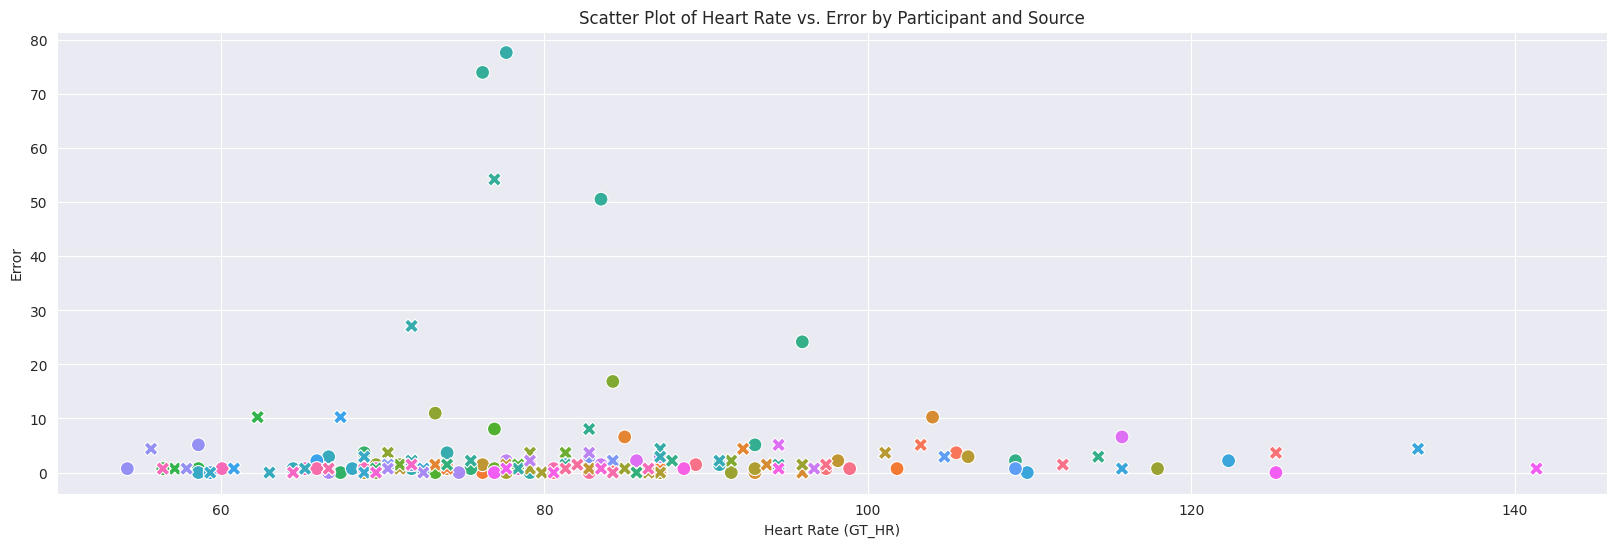

No. of Participants in dataset:  45
---.---.---.---.---.---.---.---.---.---.
HI44214245
2
--
HI44214245
2
--------------------------------------------------
1.46484375 2.197265625
---.---.---.---.---.---.---.---.---.---.
VL31214245
2
--
VL31214245
2
--------------------------------------------------
13.18359375 2.5634765625
---.---.---.---.---.---.---.---.---.---.
JD31324245
2
--
JD31324245
2
--------------------------------------------------
1.8310546875 1.0986328125
---.---.---.---.---.---.---.---.---.---.
HD37214245
2
--
HD37214245
2
--------------------------------------------------
1.8310546875 0.3662109375
---.---.---.---.---.---.---.---.---.---.
CC36344245
2
--
CC36344245
2
--------------------------------------------------
1.0986328125 5.4931640625
---.---.---.---.---.---.---.---.---.---.
ON20344245
2
--
ON20344245
2
--------------------------------------------------
1.0986328125 0.732421875
---.---.---.---.---.---.---.---.---.---.
MY37214245
2
--
MY37214245
2
-----------------

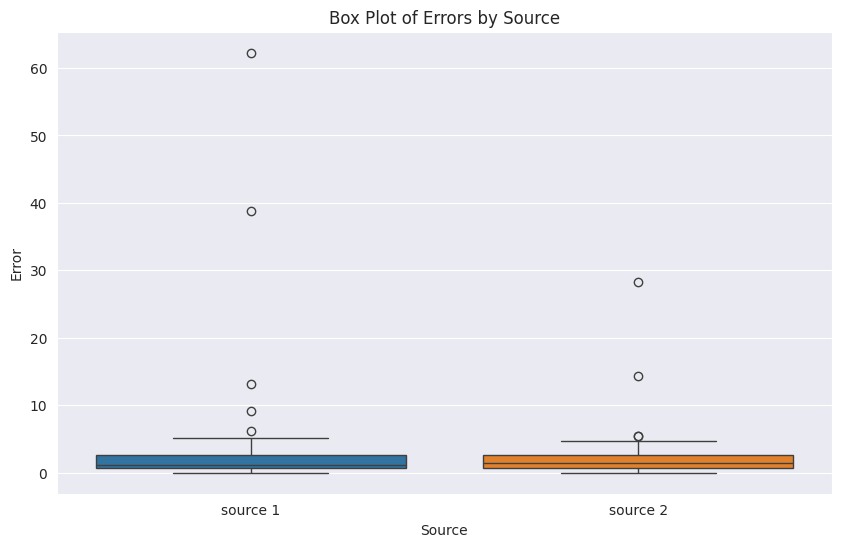

--------------------------------------------------
0     -0.732422
1     10.620117
2      0.732422
3      1.464844
4     -4.394531
5      0.366211
6     -0.366211
7     -4.760742
8      0.732422
9      0.000000
10     0.732422
11     4.394531
12     3.295898
13     0.000000
14     0.366211
15    -0.366211
16     6.958008
17    34.057617
18    -1.098633
19    35.522461
20     0.000000
21     0.366211
22    -0.366211
23     0.000000
24    -1.831055
25     2.563477
26   -12.084961
27     0.366211
28     0.366211
29    -0.732422
30     0.732422
31    -2.197266
32     0.732422
33     0.000000
34    -0.366211
35     0.366211
36    -0.366211
37    -1.464844
38     1.464844
39    -0.732422
40    -0.366211
41    -0.366211
42    -1.098633
43     0.366211
44    -1.464844
dtype: float64
No significant difference detected between scenarios.
physnet
Using CHILL dataset
Defining scenarios
This is performed on illumination splits


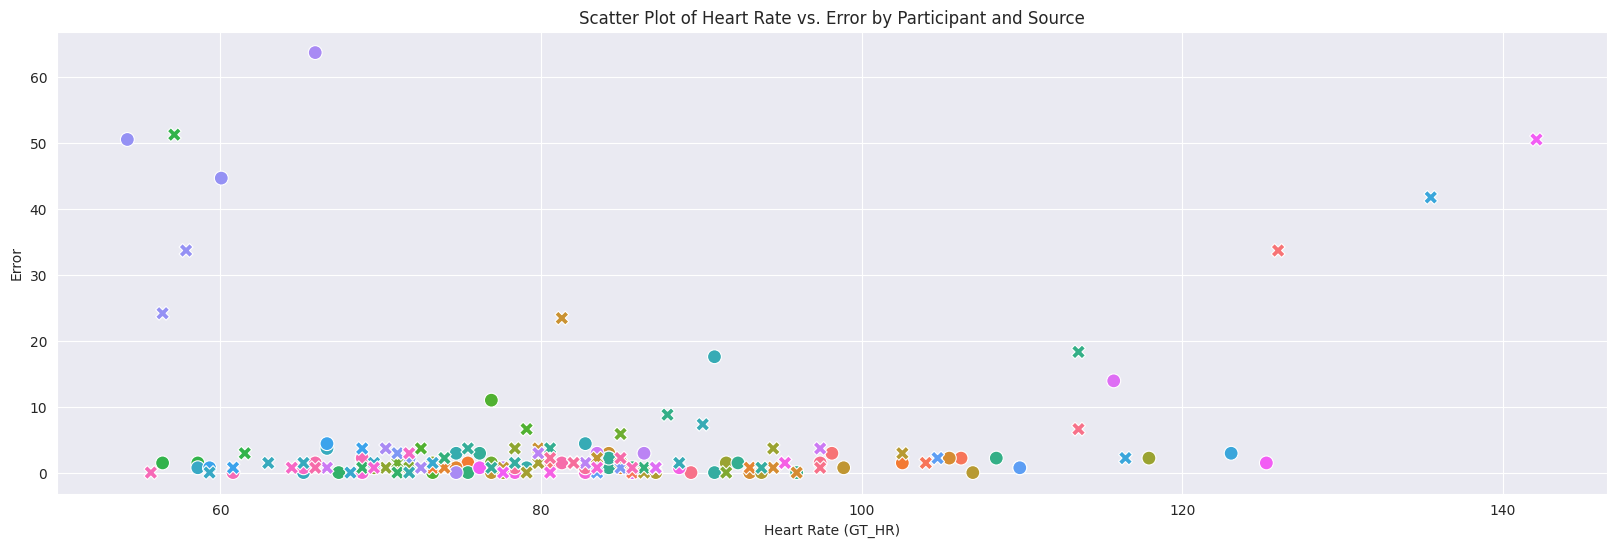

No. of Participants in dataset:  45
---.---.---.---.---.---.---.---.---.---.
HI44214245
2
--
HI44214245
2
--------------------------------------------------
0.3662109375 1.8310546875
---.---.---.---.---.---.---.---.---.---.
VL31214245
2
--
VL31214245
2
--------------------------------------------------
1.0986328125 13.5498046875
---.---.---.---.---.---.---.---.---.---.
JD31324245
2
--
JD31324245
2
--------------------------------------------------
1.0986328125 0.3662109375
---.---.---.---.---.---.---.---.---.---.
HD37214245
2
--
HD37214245
2
--------------------------------------------------
1.8310546875 1.46484375
---.---.---.---.---.---.---.---.---.---.
CC36344245
2
--
CC36344245
2
--------------------------------------------------
2.5634765625 2.197265625
---.---.---.---.---.---.---.---.---.---.
ON20344245
2
--
ON20344245
2
--------------------------------------------------
1.46484375 2.197265625
---.---.---.---.---.---.---.---.---.---.
MY37214245
2
--
MY37214245
2
-----------------

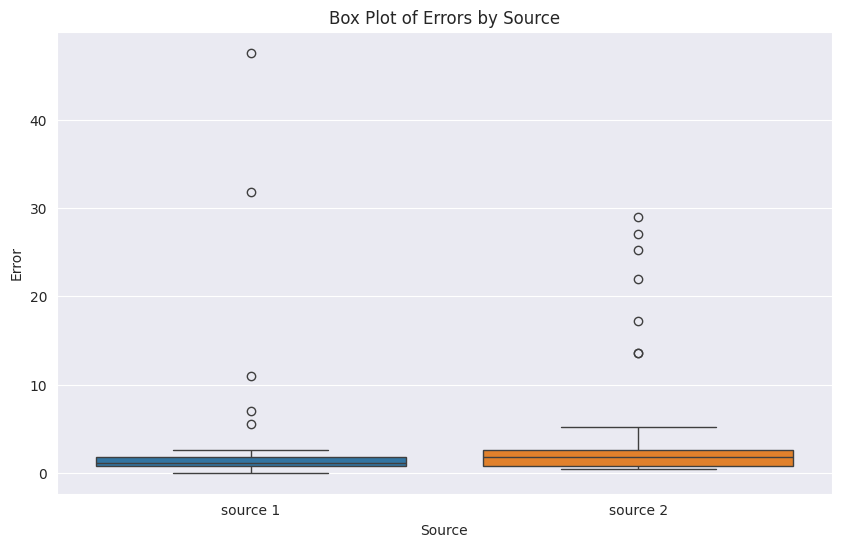

--------------------------------------------------
0     -1.464844
1    -12.451172
2      0.732422
3      0.366211
4      0.366211
5     -0.732422
6     29.663086
7    -25.634766
8      0.000000
9     -1.098633
10    -0.366211
11     0.732422
12     0.366211
13    -0.366211
14    -0.366211
15    -1.098633
16     1.098633
17     0.366211
18     6.591797
19     0.000000
20     0.732422
21   -11.718750
22    -0.732422
23    -0.366211
24   -15.380859
25    -1.098633
26     1.098633
27     0.000000
28     0.000000
29    -0.732422
30    -1.098633
31    -2.563477
32    -1.098633
33    -0.732422
34     0.732422
35    -0.366211
36    -2.929688
37    -1.464844
38     5.859375
39   -24.169922
40     0.732422
41    -0.366211
42     0.366211
43    18.676758
44   -20.141602
dtype: float64
No significant difference detected between scenarios.
rppgnet
Using CHILL dataset
Defining scenarios
This is performed on illumination splits


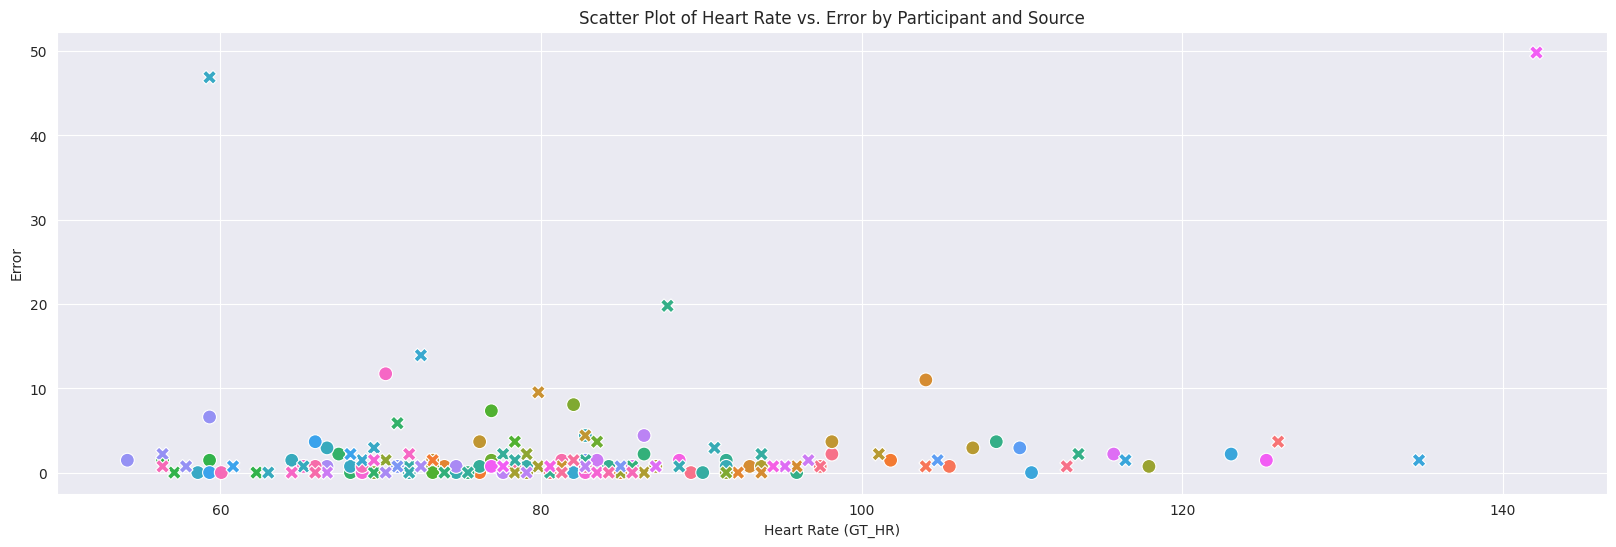

No. of Participants in dataset:  45
---.---.---.---.---.---.---.---.---.---.
HI44214245
2
--
HI44214245
2
--------------------------------------------------
1.8310546875 1.46484375
---.---.---.---.---.---.---.---.---.---.
VL31214245
2
--
VL31214245
2
--------------------------------------------------
1.8310546875 10.986328125
---.---.---.---.---.---.---.---.---.---.
JD31324245
2
--
JD31324245
2
--------------------------------------------------
1.0986328125 2.9296875
---.---.---.---.---.---.---.---.---.---.
HD37214245
2
--
HD37214245
2
--------------------------------------------------
2.197265625 0.3662109375
---.---.---.---.---.---.---.---.---.---.
CC36344245
2
--
CC36344245
2
--------------------------------------------------
1.8310546875 1.46484375
---.---.---.---.---.---.---.---.---.---.
ON20344245
2
--
ON20344245
2
--------------------------------------------------
0.732421875 0.732421875
---.---.---.---.---.---.---.---.---.---.
MY37214245
2
--
MY37214245
2
----------------------

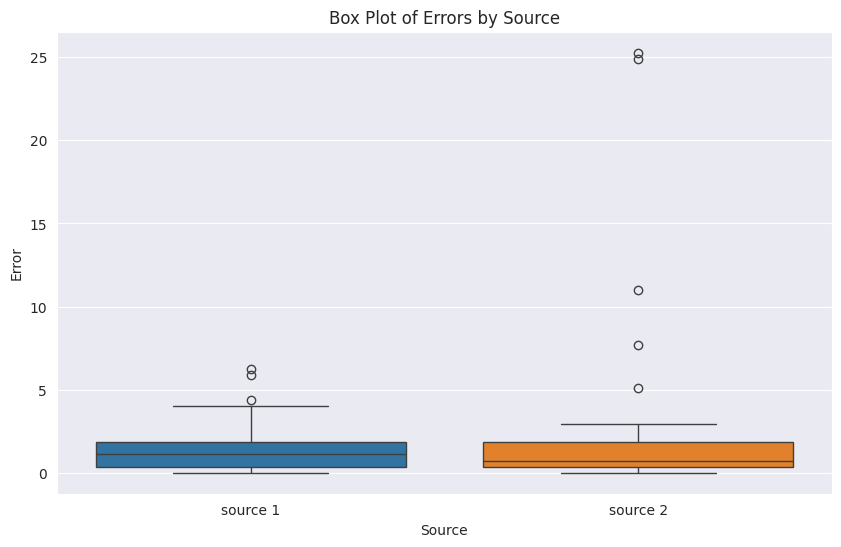

--------------------------------------------------
0      0.366211
1     -9.155273
2     -1.831055
3      1.831055
4      0.366211
5      0.000000
6      0.366211
7      1.464844
8      0.366211
9      0.732422
10    -7.690430
11     5.493164
12     1.464844
13    -0.366211
14     0.366211
15     0.000000
16     4.394531
17    -0.366211
18     0.732422
19    -0.366211
20     0.000000
21    -4.028320
22     0.732422
23     5.126953
24    -1.464844
25    -1.464844
26    -0.366211
27     0.366211
28     1.098633
29     0.000000
30    -1.831055
31    -1.098633
32     1.098633
33    -0.732422
34    -0.366211
35     0.366211
36     0.366211
37     0.366211
38     0.732422
39   -24.169922
40     0.000000
41     1.831055
42   -24.536133
43     2.563477
44    -0.366211
dtype: float64
No significant difference detected between scenarios.


,model,test_Used,t_statistic,p_value,cohen_d,effect_size_r,median_samples1,median_samples2
0,deepPhys,Wilcoxon Signed-Rank Test,466.0,0.932612,-0.061477,-0.086656,2.197266,2.929688
1,tscan,Wilcoxon Signed-Rank Test,373.5,0.621526,0.201843,-0.242301,1.098633,1.464844
2,physnet,Wilcoxon Signed-Rank Test,301.0,0.091961,-0.151019,-0.364293,1.098633,1.831055
3,rppgnet,Wilcoxon Signed-Rank Test,385.0,0.735101,-0.187041,-0.222951,1.098633,0.732422


In [31]:
results_CMBP = []
dataset = "CHILL"

for model, model_name in zip(models, model_names):

    print(model_name)
    chill_statistical_tests = statistical_tests(model, model_name, dataset)
    results_CMBP.append(chill_statistical_tests.paired_wilcoxen_test_on_illumination_groups(debug=True))

results_df = pd.DataFrame(results_CMBP)
results_df

Using CHILL dataset
Defining scenarios
This is performed on hr splits


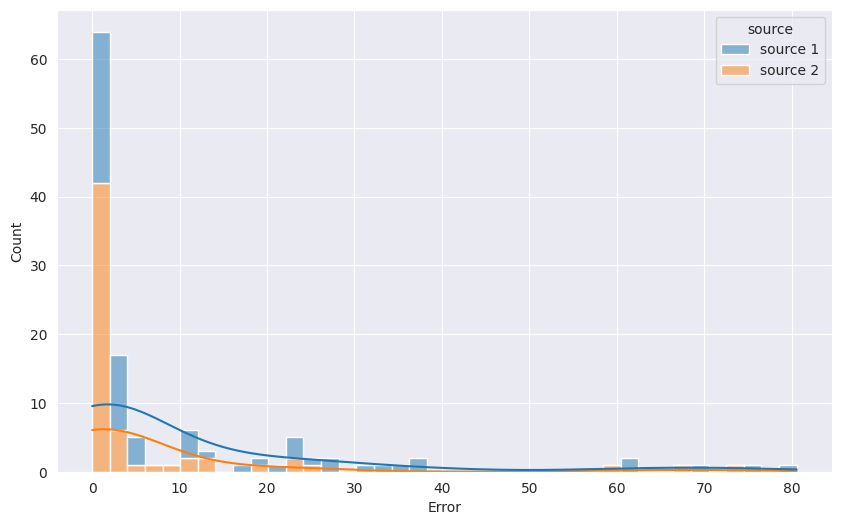

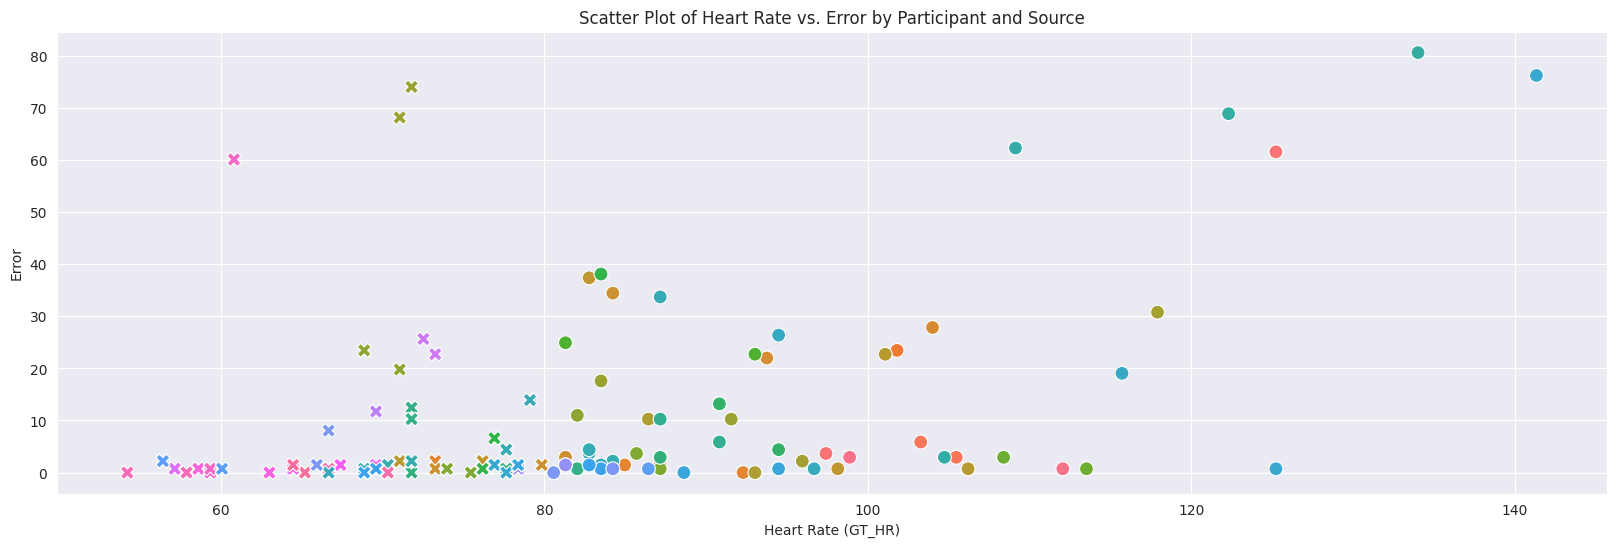

No. of Participants in dataset:  21
---.---.---.---.---.---.---.---.---.---.
CJ48324245
2
--
CJ48324245
2
--------------------------------------------------
18.6767578125 1.0986328125
---.---.---.---.---.---.---.---.---.---.
NN30214245
2
--
NN30214245
2
--------------------------------------------------
0.3662109375 4.7607421875
---.---.---.---.---.---.---.---.---.---.
NY20214245
1
--
NY20214245
2
--------------------------------------------------
1.46484375 0.3662109375
---.---.---.---.---.---.---.---.---.---.
NP44214245
2
--
NP44214245
1
--------------------------------------------------
8.7890625 1.46484375
---.---.---.---.---.---.---.---.---.---.
NU34214245
1
--
NU34214245
2
--------------------------------------------------
10.986328125 21.6064453125
---.---.---.---.---.---.---.---.---.---.
LY31324245
2
--
LY31324245
1
--------------------------------------------------
0.3662109375 1.46484375
---.---.---.---.---.---.---.---.---.---.
IH29344245
1
--
IH29344245
2
-------------------

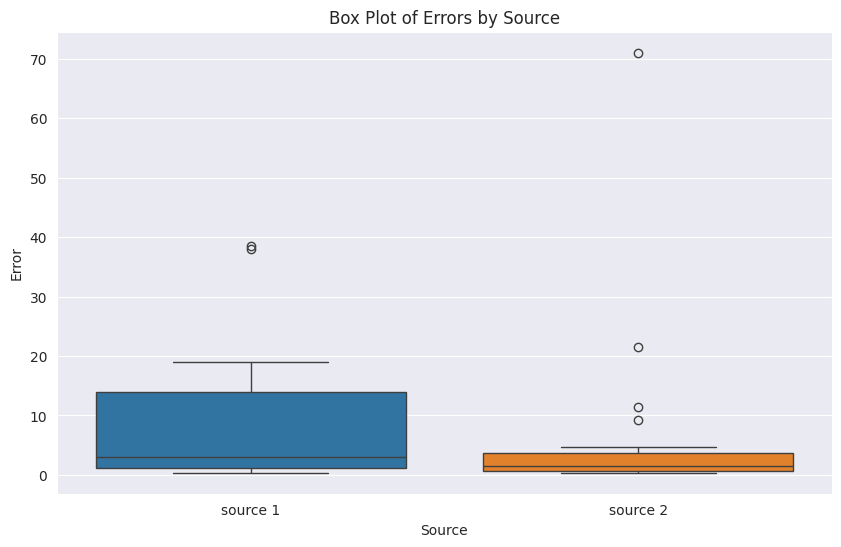

--------------------------------------------------
0     17.578125
1     -4.394531
2      1.098633
3      7.324219
4    -10.620117
5     -1.098633
6     -0.732422
7      0.732422
8    -10.620117
9     34.423828
10     0.732422
11    37.719727
12     9.887695
13    17.578125
14     2.563477
15    10.253906
16     1.098633
17    -0.732422
18     1.831055
19   -57.128906
20    11.718750
dtype: float64
No significant difference detected between scenarios.
Using CHILL dataset
Defining scenarios
This is performed on hr splits


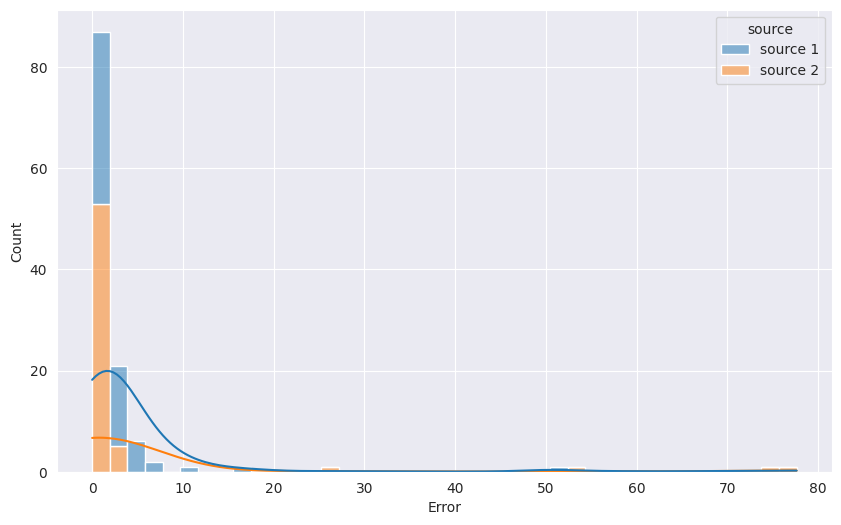

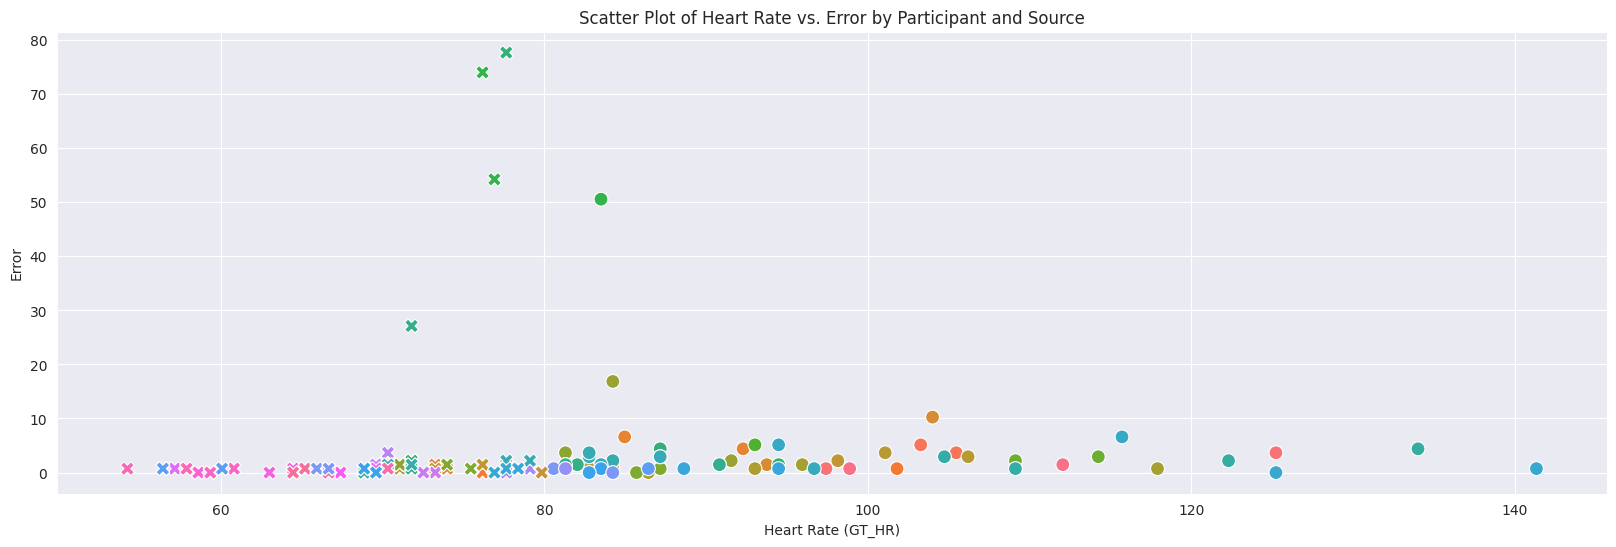

No. of Participants in dataset:  21
---.---.---.---.---.---.---.---.---.---.
CJ48324245
2
--
CJ48324245
2
--------------------------------------------------
0.732421875 0.3662109375
---.---.---.---.---.---.---.---.---.---.
NN30214245
2
--
NN30214245
2
--------------------------------------------------
0.3662109375 0.732421875
---.---.---.---.---.---.---.---.---.---.
NY20214245
1
--
NY20214245
2
--------------------------------------------------
1.46484375 0.3662109375
---.---.---.---.---.---.---.---.---.---.
NP44214245
2
--
NP44214245
1
--------------------------------------------------
1.46484375 0.732421875
---.---.---.---.---.---.---.---.---.---.
NU34214245
1
--
NU34214245
2
--------------------------------------------------
3.662109375 0.732421875
---.---.---.---.---.---.---.---.---.---.
LY31324245
2
--
LY31324245
1
--------------------------------------------------
0.732421875 0.732421875
---.---.---.---.---.---.---.---.---.---.
IH29344245
1
--
IH29344245
2
-----------------------

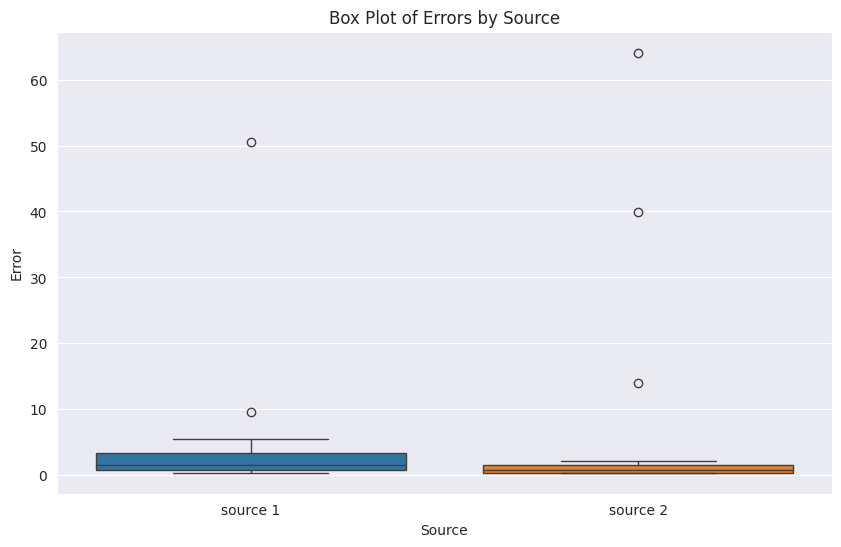

--------------------------------------------------
0      0.366211
1     -0.366211
2      1.098633
3      0.732422
4      2.929688
5      0.000000
6      0.000000
7      0.366211
8    -12.451172
9    -13.549805
10     0.000000
11     0.000000
12     1.098633
13     0.000000
14   -35.522461
15     2.929688
16     1.098633
17     4.394531
18    -0.732422
19     7.690430
20     0.366211
dtype: float64
No significant difference detected between scenarios.
Using CHILL dataset
Defining scenarios
This is performed on hr splits


/homes/bacharya/miniconda3/envs/toolbox/lib/python3.8/site-packages/scipy/stats/morestats.py:2957: UserWarning: Exact p-value calculation does not work if there are ties. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "


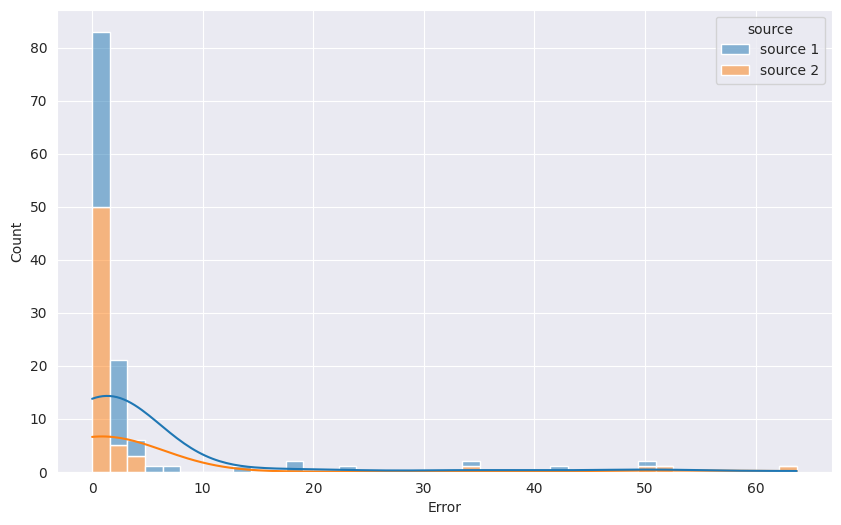

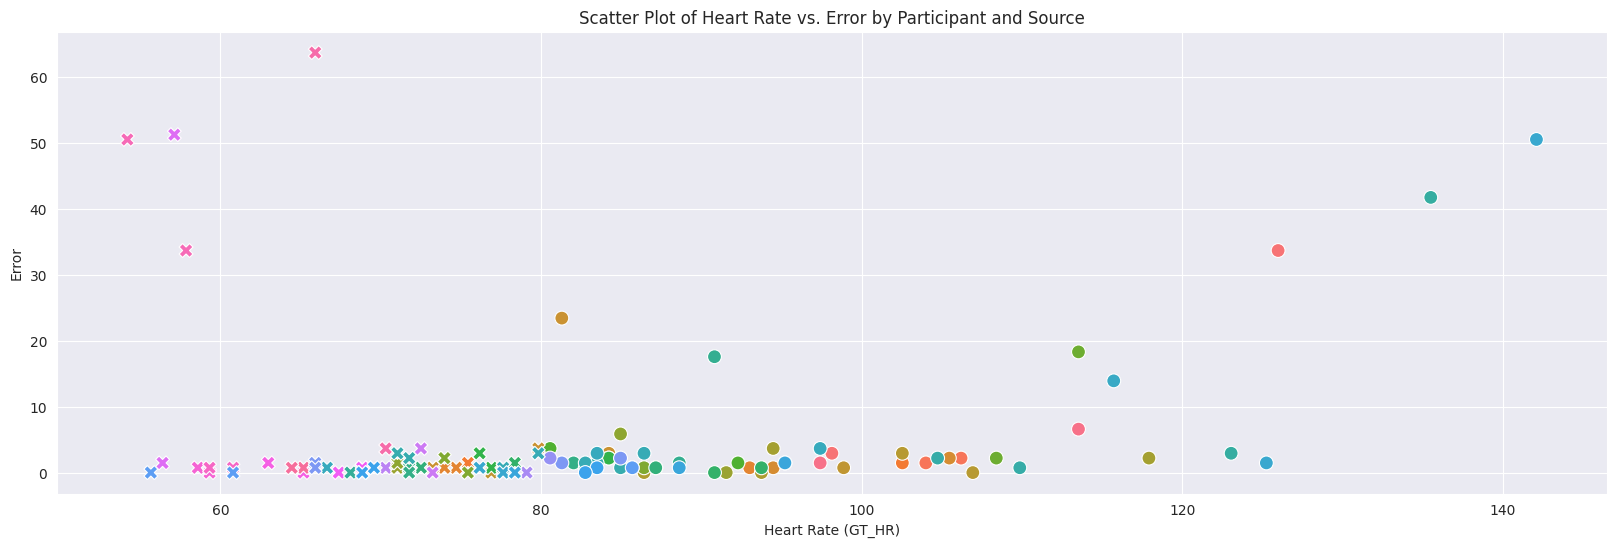

No. of Participants in dataset:  21
---.---.---.---.---.---.---.---.---.---.
CJ48324245
2
--
CJ48324245
2
--------------------------------------------------
13.18359375 2.197265625
---.---.---.---.---.---.---.---.---.---.
NN30214245
2
--
NN30214245
2
--------------------------------------------------
1.8310546875 1.0986328125
---.---.---.---.---.---.---.---.---.---.
NY20214245
1
--
NY20214245
2
--------------------------------------------------
0.732421875 0.0
---.---.---.---.---.---.---.---.---.---.
NP44214245
2
--
NP44214245
1
--------------------------------------------------
0.3662109375 1.46484375
---.---.---.---.---.---.---.---.---.---.
NU34214245
1
--
NU34214245
2
--------------------------------------------------
5.859375 1.0986328125
---.---.---.---.---.---.---.---.---.---.
LY31324245
2
--
LY31324245
1
--------------------------------------------------
1.0986328125 0.0
---.---.---.---.---.---.---.---.---.---.
IH29344245
1
--
IH29344245
2
---------------------------------------

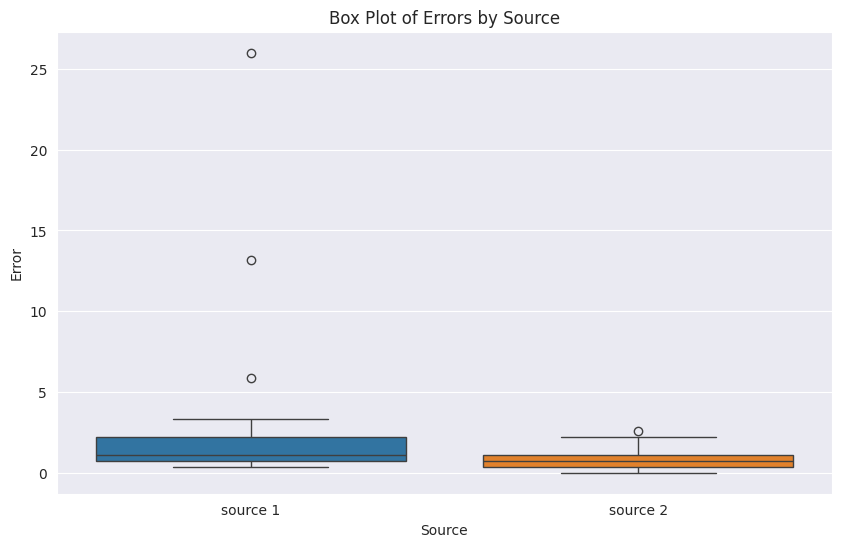

--------------------------------------------------
0     10.986328
1      0.732422
2      0.732422
3     -1.098633
4      4.760742
5      1.098633
6      0.732422
7      2.929688
8      1.098633
9      0.366211
10     0.000000
11    25.634766
12     0.366211
13     1.098633
14     0.000000
15     0.732422
16    -1.464844
17     0.000000
18    -0.366211
19     0.366211
20     0.000000
dtype: float64
Significant difference detected between scenarios!
Using CHILL dataset
Defining scenarios
This is performed on hr splits


/homes/bacharya/miniconda3/envs/toolbox/lib/python3.8/site-packages/scipy/stats/morestats.py:2957: UserWarning: Exact p-value calculation does not work if there are ties. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "


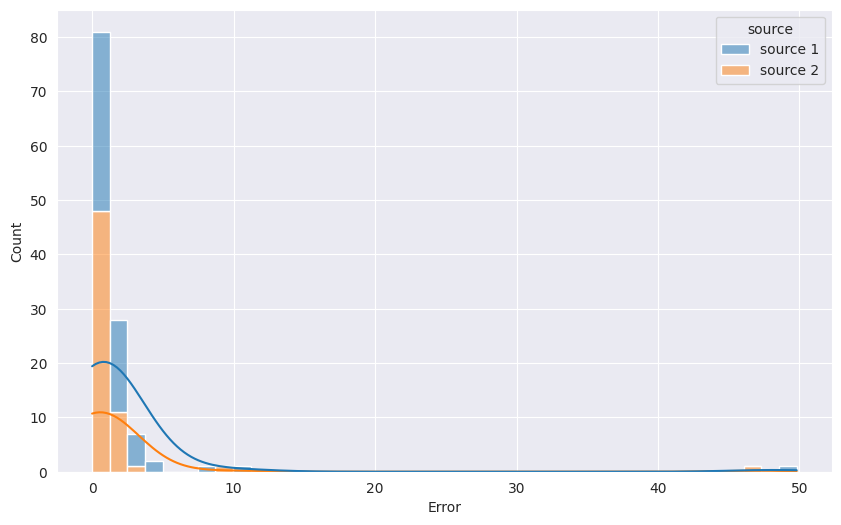

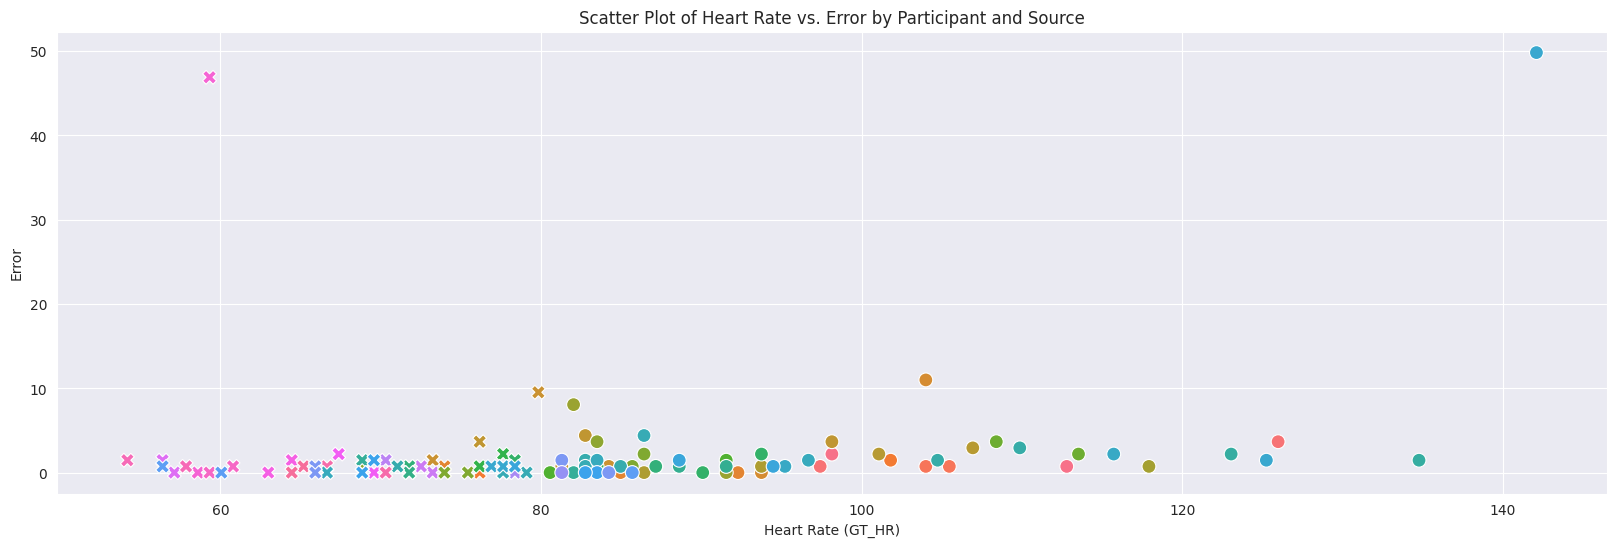

No. of Participants in dataset:  21
---.---.---.---.---.---.---.---.---.---.
CJ48324245
2
--
CJ48324245
2
--------------------------------------------------
0.732421875 5.4931640625
---.---.---.---.---.---.---.---.---.---.
NN30214245
2
--
NN30214245
2
--------------------------------------------------
0.732421875 0.3662109375
---.---.---.---.---.---.---.---.---.---.
NY20214245
1
--
NY20214245
2
--------------------------------------------------
0.0 0.732421875
---.---.---.---.---.---.---.---.---.---.
NP44214245
2
--
NP44214245
1
--------------------------------------------------
1.0986328125 1.46484375
---.---.---.---.---.---.---.---.---.---.
NU34214245
1
--
NU34214245
2
--------------------------------------------------
3.662109375 0.732421875
---.---.---.---.---.---.---.---.---.---.
LY31324245
2
--
LY31324245
1
--------------------------------------------------
1.0986328125 0.732421875
---.---.---.---.---.---.---.---.---.---.
IH29344245
1
--
IH29344245
2
-----------------------------

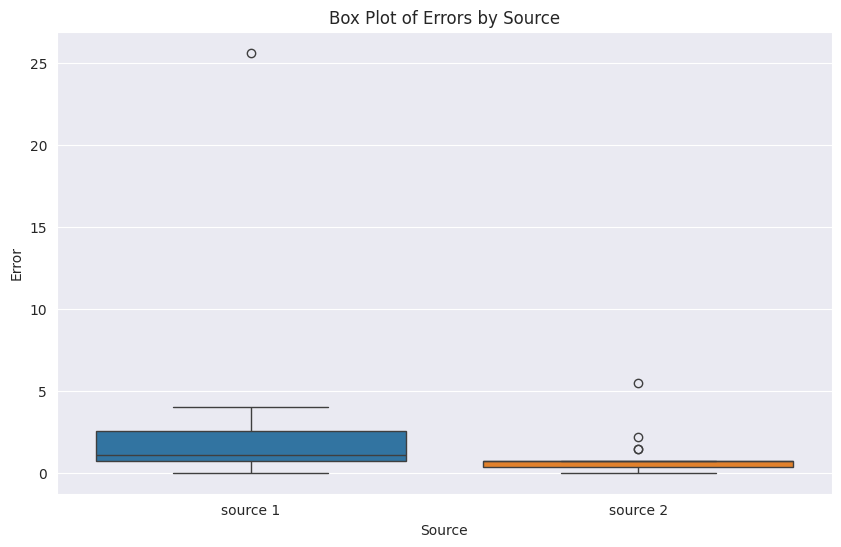

--------------------------------------------------
0     -4.760742
1      0.366211
2     -0.732422
3     -0.366211
4      2.929688
5      0.366211
6     -0.366211
7      1.464844
8      0.732422
9     -0.732422
10    -0.732422
11    24.902344
12     2.563477
13     1.831055
14     0.366211
15     1.831055
16     0.366211
17    -0.366211
18     1.464844
19     3.662109
20     0.366211
dtype: float64
No significant difference detected between scenarios.


,model,test_Used,t_statistic,p_value,cohen_d,effect_size_r,median_samples1,median_samples2
0,deepPhys,Wilcoxon Signed-Rank Test,71.0,0.128078,0.177242,-0.337521,2.929688,1.464844
1,tscan,Wilcoxon Signed-Rank Test,53.0,0.436738,-0.208823,-0.474046,1.464844,0.732422
2,physnet,Wilcoxon Signed-Rank Test,26.0,0.016365,0.390431,-0.678834,1.098633,0.732422
3,rppgnet,Wilcoxon Signed-Rank Test,65.0,0.082195,0.299063,-0.383029,1.098633,0.732422


In [33]:
results_CMBP = []
dataset = "CHILL"

for model, model_name in zip(models, model_names):

    chill_statistical_tests = statistical_tests(model, model_name, dataset)
    results_CMBP.append(chill_statistical_tests.paired_wilcoxen_test_on_hr_groups(debug=True))

results_df = pd.DataFrame(results_CMBP)
results_df

# Classical methods on CMBP

In [34]:
workspace = "b-acharya"  # Replace with your Comet workspace name

#this is different for each project
project_name = "dst-dataset-unsupervised"  # Replace with your project name


In [35]:
experiments = api.get_experiments(workspace=workspace, project_name=project_name)

In [36]:
# Classical methods
#CMBP and differnt models 

CMBP_POS_experiments = []
CMBP_GREEN_experiments = []
CMBP_CHROM_experiments = []
CMBP_ICA_experiments = []

for experiment in experiments:
    print(f"Experiment Name: {experiment.name}")
    experiment_name = experiment.name
    
    if "POS" in experiment_name:
        if "arxiv" in experiment.get_tags() and "CMBP" in experiment.get_tags():
            CMBP_POS_experiments.append(experiment)
        
        continue
    
    elif "GREEN" in experiment_name:
        if "arxiv" in experiment.get_tags() and "CMBP" in experiment.get_tags():
            CMBP_GREEN_experiments.append(experiment)
        continue
    
    elif "ICA" in experiment_name:
        if "arxiv" in experiment.get_tags() and "CMBP" in experiment.get_tags():
            CMBP_ICA_experiments.append(experiment)
        continue
        
    elif "CHROM" in experiment_name:
        if "arxiv" in experiment.get_tags() and "CMBP" in experiment.get_tags():
            CMBP_CHROM_experiments.append(experiment)
        continue

Experiment Name: ICA
Experiment Name: POS
Experiment Name: CHROM
Experiment Name: GREEN
Experiment Name: LGI
Experiment Name: PBV
Experiment Name: ICA
Experiment Name: POS
Experiment Name: CHROM
Experiment Name: GREEN
Experiment Name: LGI
Experiment Name: PBV
Experiment Name: ICA
Experiment Name: POS
Experiment Name: CHROM
Experiment Name: GREEN
Experiment Name: LGI
Experiment Name: PBV
Experiment Name: dummy
Experiment Name: random
Experiment Name: random
Experiment Name: Tscan_DST_
Experiment Name: ICA
Experiment Name: ICA
Experiment Name: Tscan_DST_
Experiment Name: ICA
Experiment Name: POS
Experiment Name: ICA
Experiment Name: ICA
Experiment Name: ICA
Experiment Name: POS
Experiment Name: CHROM
Experiment Name: GREEN
Experiment Name: LGI
Experiment Name: PBV
Experiment Name: dummy
Experiment Name: ICA
Experiment Name: ICA
Experiment Name: ICA
Experiment Name: ICA
Experiment Name: POS
Experiment Name: CHROM
Experiment Name: GREEN
Experiment Name: LGI
Experiment Name: PBV
Experiment 

In [37]:
POS_CMBP_df = get_dataframe(CMBP_POS_experiments)

GREEN_CMBP_df = get_dataframe(CMBP_GREEN_experiments)

ICA_CMBP_df = get_dataframe(CMBP_ICA_experiments)

CHROM_CMBP_df = get_dataframe(CMBP_CHROM_experiments)

In [38]:

len(POS_CMBP_df), len(CHROM_CMBP_df), len(GREEN_CMBP_df), len(ICA_CMBP_df)

fold_CMBP_mae_POS_df = POS_CMBP_df.groupby('FOLD')['Error'].mean()
fold_CMBP_mae_GREEN_df = GREEN_CMBP_df.groupby('FOLD')['Error'].mean()
fold_CMBP_mae_ICA_df = ICA_CMBP_df.groupby('FOLD')['Error'].mean()
fold_CMBP_mae_CHROM_df = CHROM_CMBP_df.groupby('FOLD')['Error'].mean()

print(fold_CMBP_mae_POS_df.mean())
print(fold_CMBP_mae_GREEN_df.mean())
print(fold_CMBP_mae_ICA_df.mean())
print(fold_CMBP_mae_CHROM_df.mean())


1.08642578125
2.60009765625
5.38330078125
1.7659505208333333


In [25]:

def modify_datafram_CMBP(df):
    df.reset_index(inplace=True)
    df['scenario'] = df['Participant-ID'].str[-1:].astype(int)
    df['Participant'] = df['Participant-ID'].str[2:-2]
    return df


models = [POS_CMBP_df, GREEN_CMBP_df, ICA_CMBP_df, CHROM_CMBP_df]
model_names = ["POS", "GREEN", "ICA", "CHROM"]

results_CMBP = []
dataset = "CMBP"

for model, model_name in zip(models, model_names):
    ttest_metrics = perform_ttest_per_fold(model, model_name, dataset, type="Illumination", debug=False)
    results_CMBP.append(ttest_metrics)

results_df = pd.DataFrame(results_CMBP)
results_df

KeyError: 'scenario'

In [15]:
models = [ deepPhys_CMBP_df, tscan_CMBP_df, physnet_CMBP_df, rppgnet_CMBP_df ]
model_names = ["deepPhys", "tscan", "physnet", "rppgnet"]

results_CMBP = []
dataset = "CMBP"

for model, model_name in zip(models, model_names):

    ttest_metrics = perform_ttest_per_fold(model, model_name, dataset, type="Illumination", debug=False)
    results_CMBP.append(ttest_metrics)

results_df = pd.DataFrame(results_CMBP)
results_df

NameError: name 'tscan_CMBP_df' is not defined

In [ ]:
results_CMBP = []
dataset = "CMBP"

for model, model_name in zip(models, model_names):

    ttest_overall_metrics = perform_ttest_participant(model, model_name, dataset, type="Illumination", debug=False)
    results_CMBP.append(ttest_overall_metrics)

results_df = pd.DataFrame(results_CMBP)
results_df

In [ ]:
results_CMBP = []
dataset = "CMBP"

for model, model_name in zip(models, model_names):

    ttest_overall_metrics = perform_ttest_per_fold(model, model_name, dataset, type="HR", debug=False)
    results_CMBP.append(ttest_overall_metrics)

results_df = pd.DataFrame(results_CMBP)
results_df


In [ ]:
results_CMBP = []
dataset = "CMBP"

for model, model_name in zip(models, model_names):

    ttest_overall_metrics = perform_ttest_participant(model, model_name, dataset, type="HR", debug=False)
    results_CMBP.append(ttest_overall_metrics)

results_df = pd.DataFrame(results_CMBP)
results_df


----------------------------------------
POS
defaultdict(<class 'list'>, {})


/Users/bhargavacharya/miniconda3/envs/xlx/lib/python3.10/site-packages/numpy/core/_methods.py:262: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/bhargavacharya/miniconda3/envs/xlx/lib/python3.10/site-packages/numpy/core/_methods.py:254: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


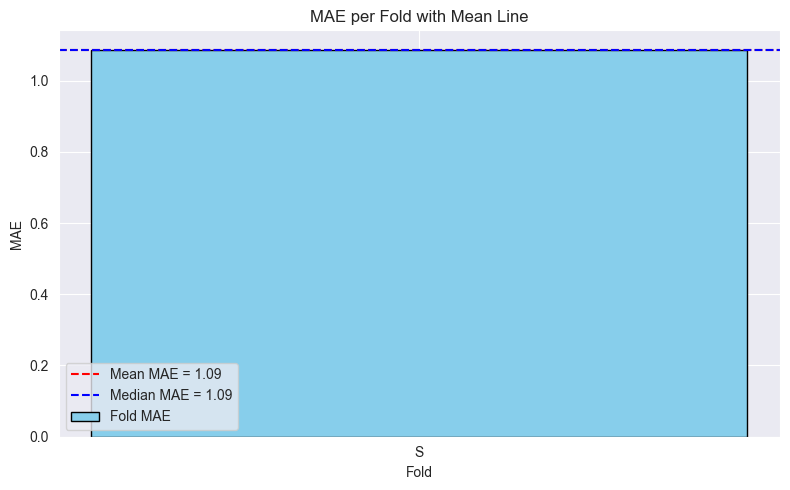

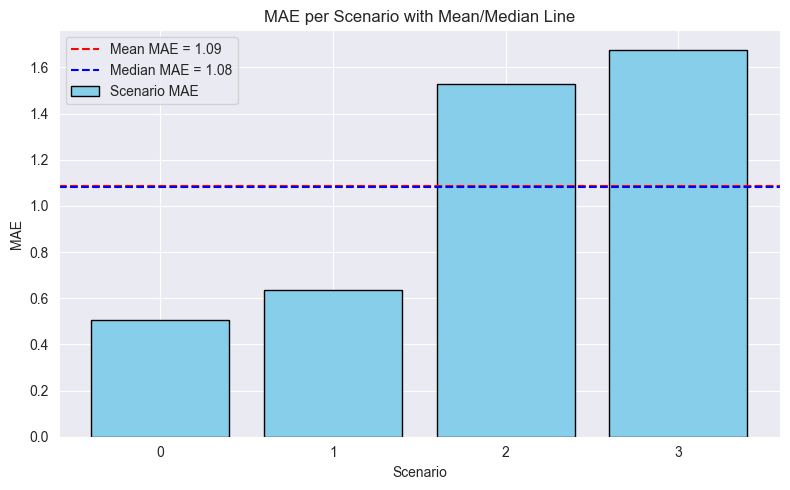


Overall MAE:  1.08642578125

Overall MAE:  1.08642578125
----------------------------------------
GREEN
defaultdict(<class 'list'>, {})


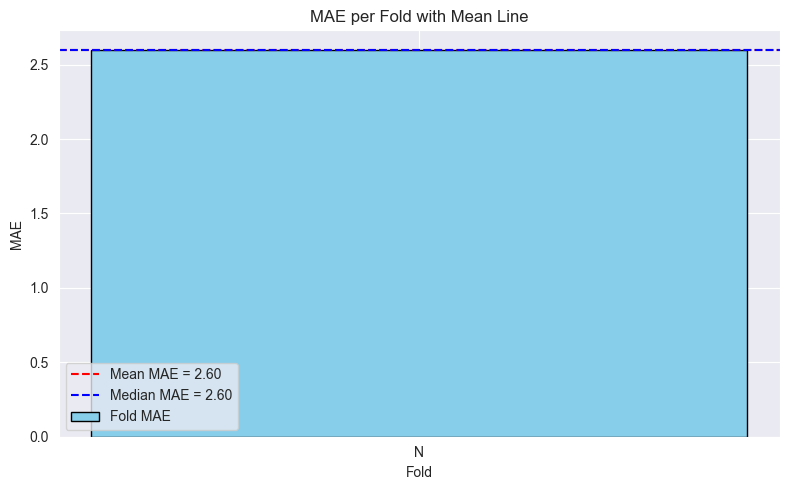

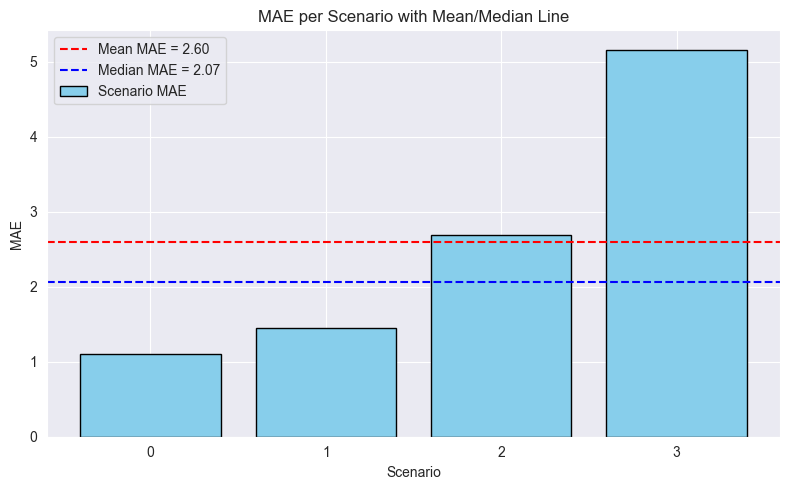


Overall MAE:  2.60009765625

Overall MAE:  2.60009765625
----------------------------------------
CHROM
defaultdict(<class 'list'>, {})


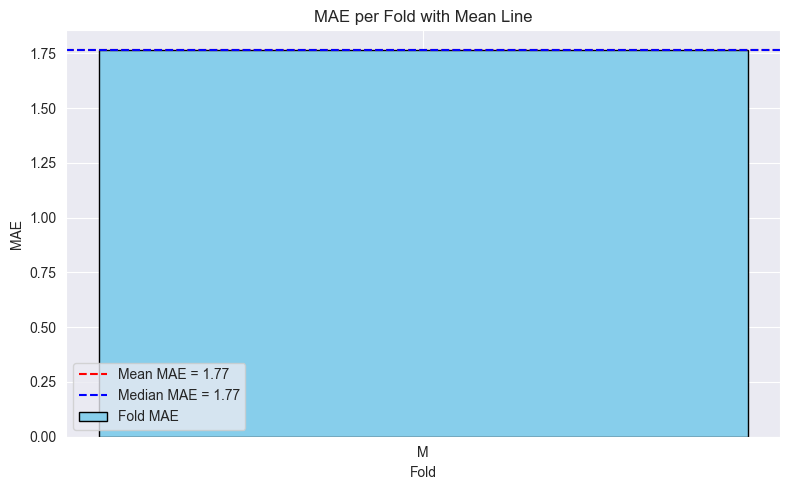

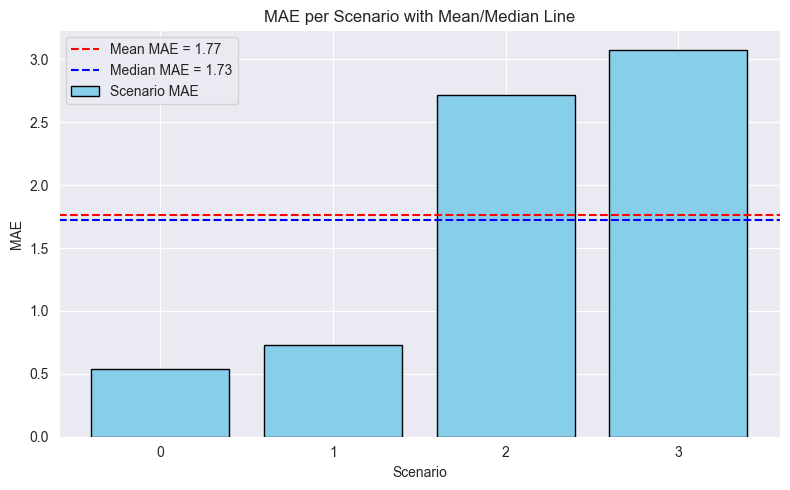


Overall MAE:  1.7659505208333333

Overall MAE:  1.7659505208333335
----------------------------------------
ICA
defaultdict(<class 'list'>, {})


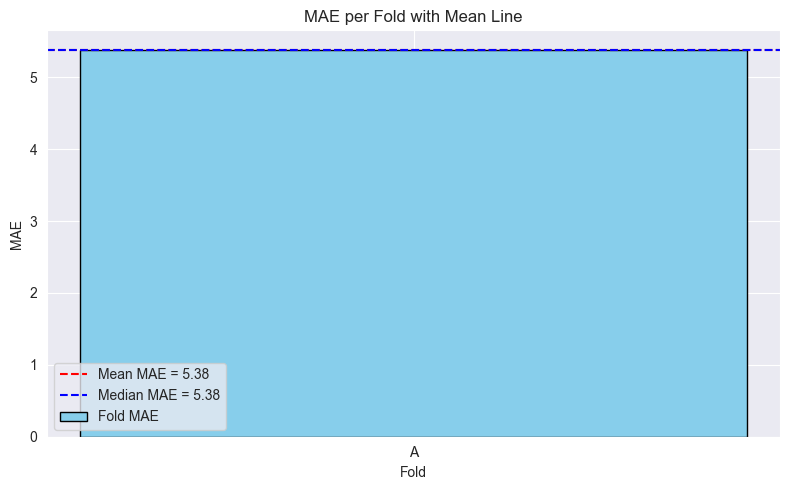

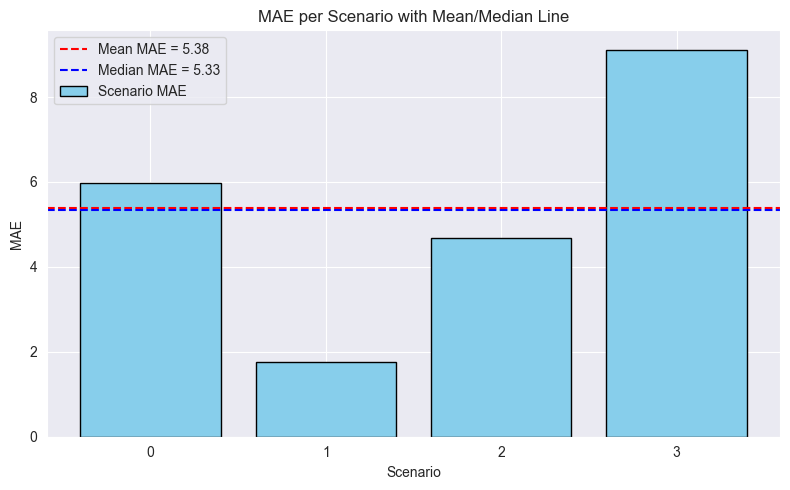


Overall MAE:  5.38330078125

Overall MAE:  5.38330078125
----------------------------------------


In [18]:
# POS CMBP
model_metrics = {}
scenarios_metrics = {}
errors_per_fold_per_scenario = {}
errors_per_fold_per_HR_SPLIT = {}

print("-"*40)
print("POS")
model_metrics['POS'], scenarios_metrics['POS'], errors_per_fold_per_scenario['POS'], errors_per_fold_per_HR_SPLIT['POS'] =  calculate_metrics(CMBP_POS_experiments)
print("-"*40)

print("GREEN")
model_metrics['GREEN'], scenarios_metrics['GREEN'], errors_per_fold_per_scenario['GREEN'], errors_per_fold_per_HR_SPLIT['GREEN'] =  calculate_metrics(CMBP_GREEN_experiments)
print("-"*40)

print("CHROM")
model_metrics['CHROM'], scenarios_metrics['CHROM'], errors_per_fold_per_scenario['CHROM'], errors_per_fold_per_HR_SPLIT['CHROM'] =  calculate_metrics(CMBP_CHROM_experiments)
print("-"*40)

print("ICA")
model_metrics['ICA'], scenarios_metrics['ICA'], errors_per_fold_per_scenario['ICA'], errors_per_fold_per_HR_SPLIT['ICA'] =  calculate_metrics(CMBP_ICA_experiments)
print("-"*40)


<Axes: >

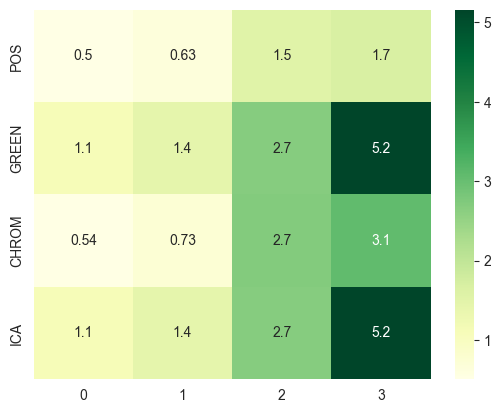

In [16]:
import seaborn as sns
df = pd.DataFrame.from_dict(scenarios_metrics).T
df
sns.heatmap(df, annot=True, cmap='YlGn')

In [19]:
scenarios_metrics

{'POS': defaultdict(list,
             {'0': 0.5045572916666666,
              '1': 0.634765625,
              '2': 1.5299479166666667,
              '3': 1.6764322916666667}),
 'GREEN': defaultdict(list,
             {'0': 1.1067708333333333,
              '1': 1.4485677083333333,
              '2': 2.685546875,
              '3': 5.159505208333333}),
 'CHROM': defaultdict(list,
             {'0': 0.537109375,
              '1': 0.732421875,
              '2': 2.7180989583333335,
              '3': 3.076171875}),
 'ICA': defaultdict(list,
             {'0': 5.973307291666667,
              '1': 1.7578125,
              '2': 4.6875,
              '3': 9.114583333333334})}